# Wind CARMA(4,3) QMLE, Levy recovery, and physical diagnostics

This notebook consumes the CARMA(4,3) initialisation from `01order_wind`
and runs the same exact Gaussian prediction-error QMLE, Levy recovery, driver
law calibration, simulations, and posterior predictive checks used for the weather marginal models. The stochastic series is the deseasonalised wind residual
`wind_XtQ`.


In [1]:
%matplotlib inline

from pathlib import Path
import json
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import cumulative_trapezoid
from scipy.linalg import expm, solve_continuous_lyapunov
from scipy.optimize import minimize
from scipy.special import kve
from scipy.stats import norm, norminvgauss

plt.rcParams.update({
    "figure.figsize": (9, 4),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 10,
})

CWD = Path.cwd().resolve()
if (CWD / "wind").exists() and (CWD / "germany").exists():
    REPO = CWD
    CODE = REPO / "wind" / "carma_coupling"
elif CWD.name.lower() == "carma_coupling" and CWD.parent.name.lower() == "wind":
    CODE = CWD
    REPO = CODE.parents[1]
elif CWD.name.lower() == "wind":
    REPO = CWD.parent
    CODE = CWD / "carma_coupling"
else:
    raise FileNotFoundError("Run this notebook from the repo root, wind/, or wind/carma_coupling/. Run 01order_wind first.")

DATA = CODE / "data" / "carma"
OUT = DATA
FIG = CODE / "figures" / "carma"
OUT.mkdir(parents=True, exist_ok=True)
FIG.mkdir(parents=True, exist_ok=True)

WIND_BUNDLE = REPO / "wind" / "Gabriel"
if str(WIND_BUNDLE) not in sys.path:
    sys.path.insert(0, str(WIND_BUNDLE))

from intensity_data import DEFAULT_WIND_PATH, logit_capacity_factor
from intensity_seasonality import fit_mle_notebook_seasonality

panel_path = OUT / "wind_latent_panel.csv"
metadata_path = OUT / "wind_latent_metadata.json"
PRICE_PANEL_PATH = REPO / "germany" / "germany23+24+25" / "data" / "seasonality" / "german_panel.csv"
SOURCE_WIND_PATH = DEFAULT_WIND_PATH


def load_wind_capacity_factor_utc(path: str | Path) -> pd.Series:
    raw = pd.read_csv(path, sep=";", decimal=",")
    timestamp = pd.to_datetime(raw["DateTimeUTC"], format="%d.%m.%Y %H:%M", errors="coerce", utc=True)
    wind_col = next(col for col in raw.columns if "wind" in col.lower())
    series = pd.Series(pd.to_numeric(raw[wind_col], errors="coerce").to_numpy(float), index=timestamp, name="wind_cf")
    series = series.dropna().sort_index()
    series = series[~series.index.duplicated(keep="first")]
    series = series.asfreq("1h").ffill(limit=3).dropna()
    if float(series.max()) > 1.5:
        series = series / 100.0
    return series.clip(0.0, 1.0).rename("wind_cf")


def build_wind_latent_panel():
    price_panel = pd.read_csv(PRICE_PANEL_PATH, parse_dates=["datetime"])
    price_index = pd.DatetimeIndex(pd.to_datetime(price_panel["datetime"], utc=True)).dropna().drop_duplicates().sort_values()
    wind_cf_source = load_wind_capacity_factor_utc(SOURCE_WIND_PATH)
    wind_cf = wind_cf_source.reindex(price_index).interpolate(method="time").ffill().bfill().rename("wind_cf")
    wind_logit = pd.Series(logit_capacity_factor(wind_cf), index=wind_cf.index, name="wind_logit")
    wind_fit = fit_mle_notebook_seasonality(wind_logit, name="wind_mle", fourier_order=2)
    panel = pd.DataFrame({
        "wind_cf": wind_cf.astype(float),
        "wind_logit": wind_logit.astype(float),
        "wind_logit_seasonality": wind_fit.fitted.astype(float),
        "wind_XtQ": wind_fit.residual.astype(float),
    })
    metadata = {
        "source": "wind/carma_coupling/02mle_wind.ipynb",
        "input_wind_path": str(SOURCE_WIND_PATH),
        "price_calendar_path": str(PRICE_PANEL_PATH),
        "series": "wind_XtQ = logit(wind_cf) - wind_logit_seasonality",
        "time_zone": "UTC",
        "unit": "logit capacity-factor units",
        "seasonality": "Same wind technique as wind/Gabriel: logit capacity factor and fit_mle_notebook_seasonality(fourier_order=2).",
    }
    panel.to_csv(panel_path)
    metadata_path.write_text(json.dumps(metadata, indent=2), encoding="utf-8")
    return panel, metadata


if panel_path.exists() and metadata_path.exists():
    panel = pd.read_csv(panel_path, index_col=0, parse_dates=True)
    wind_meta = json.loads(metadata_path.read_text(encoding="utf-8"))
else:
    panel, wind_meta = build_wind_latent_panel()

panel.index = pd.to_datetime(panel.index, utc=True)
panel = panel.dropna(subset=["wind_cf", "wind_logit", "wind_logit_seasonality", "wind_XtQ"])

wind_obs = panel["wind_logit"].to_numpy(float)
wind_level_obs = panel["wind_cf"].to_numpy(float)
wind_seasonal = panel["wind_logit_seasonality"].to_numpy(float)
pr = panel["wind_XtQ"].to_numpy(float)
valid = np.isfinite(wind_obs) & np.isfinite(wind_seasonal) & np.isfinite(pr)
panel = panel.loc[valid]
wind_obs = wind_obs[valid]
wind_level_obs = wind_level_obs[valid]
wind_seasonal = wind_seasonal[valid]
pr = pr[valid]
N = len(pr)

obs_delta_y = np.diff(pr)
obs_delta_wind = np.diff(wind_obs)
wind_identity_error = float(np.max(np.abs(wind_obs - wind_seasonal - pr)))

print(f"{N:,} hourly wind logit residuals XtQ")
print(f"XtQ empirical mean/std             = {pr.mean():.6e} / {pr.std(ddof=0):.6e}")
print(f"Delta XtQ empirical mean/std       = {obs_delta_y.mean():.6e} / {obs_delta_y.std(ddof=0):.6e}")
print(f"wind logit level mean/std          = {wind_obs.mean():.6e} / {wind_obs.std(ddof=0):.6e}")
print(f"wind capacity factor mean/std      = {wind_level_obs.mean():.6e} / {wind_level_obs.std(ddof=0):.6e}")
print(f"max |logit(wind_cf) - seasonal - XtQ| = {wind_identity_error:.3e}")


26,305 hourly wind logit residuals XtQ
XtQ empirical mean/std             = 2.057211e-15 / 1.299078e+00
Delta XtQ empirical mean/std       = -1.075522e-04 / 3.213466e-01
wind logit level mean/std          = -1.688733e+00 / 1.380457e+00
wind capacity factor mean/std      = 2.167105e-01 / 1.800042e-01
max |logit(wind_cf) - seasonal - XtQ| = 1.332e-15


In [2]:
# Discrete-time ARMA(1,0) diagnostic
import statsmodels.api as sm
y_arma = np.asarray(pr, dtype=float)
y_arma = y_arma[np.isfinite(y_arma)] - np.nanmean(y_arma)
arma10 = sm.tsa.SARIMAX(y_arma, order=(1, 0, 0), trend="n", enforce_stationarity=True, enforce_invertibility=True)
arma10_res = arma10.fit(method="lbfgs", maxiter=1000, disp=False)
print(f"ARMA(1,0): loglik={arma10_res.llf:.3f}; AIC={arma10_res.aic:.3f}; BIC={arma10_res.bic:.3f}")
display(pd.DataFrame({"param": arma10_res.param_names, "value": arma10_res.params}))


ARMA(1,0): loglik=-7261.653; AIC=14527.306; BIC=14543.661


,param,value
0,ar.L1,0.969371
1,sigma2,0.101682


In [3]:
# Discrete-time ARMA(4,3) diagnostic
import statsmodels.api as sm
y_arma = np.asarray(pr, dtype=float)
y_arma = y_arma[np.isfinite(y_arma)] - np.nanmean(y_arma)
arma43 = sm.tsa.SARIMAX(y_arma, order=(4, 0, 3), trend="n", enforce_stationarity=True, enforce_invertibility=True)
arma43_res = arma43.fit(method="lbfgs", maxiter=1000, disp=False)
print(f"ARMA(4,3): loglik={arma43_res.llf:.3f}; AIC={arma43_res.aic:.3f}; BIC={arma43_res.bic:.3f}")
display(pd.DataFrame({"param": arma43_res.param_names, "value": arma43_res.params}))


c:\Users\gabri\miniforge3\envs\carma\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\gabri\miniforge3\envs\carma\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


ARMA(4,3): loglik=-6853.455; AIC=13722.910; BIC=13788.330


,param,value
0,ar.L1,-0.469515
1,ar.L2,0.901879
2,ar.L3,0.678394
3,ar.L4,-0.230296
4,ma.L1,1.603694
5,ma.L2,0.755506
6,ma.L3,-0.076569
7,sigma2,0.098586


## 1. CARMA state-space model and root parameterisation


In [4]:
def build_companion_matrix(ar_coefficients):
    ar = np.asarray(ar_coefficients, dtype=float)
    p = len(ar)
    A = np.zeros((p, p))
    A[:-1, 1:] = np.eye(p - 1)
    A[-1, :] = -ar[::-1]

    expected = np.concatenate([[1.0], ar])
    actual = np.poly(np.linalg.eigvals(A)).real
    if not np.allclose(actual, expected, atol=1e-6):
        raise ValueError(f"Companion matrix check failed: {actual} vs {expected}")
    return A


def build_b_vector(b_coefficients, p):
    b = np.asarray(b_coefficients, dtype=float)
    q = len(b) - 1
    if q > p - 1:
        raise ValueError(f"q={q} must be <= p-1={p-1}")
    return np.concatenate([b, np.zeros(p - 1 - q)]) if q < p - 1 else b.copy()


def psd_sqrt(M, tol=1e-12):
    M = 0.5 * (M + M.T)
    vals, vecs = np.linalg.eigh(M)
    if vals.min() < -tol:
        raise ValueError(f"Matrix is not PSD; min eigenvalue={vals.min():.3e}")
    return vecs @ np.diag(np.sqrt(np.clip(vals, 0.0, None)))


def discrete_noise_covariance(A, ep, Delta=1.0):
    # Van Loan block exponential for int_0^Delta exp(Au) e e' exp(A'u) du.
    A = np.asarray(A, dtype=float)
    ep = np.asarray(ep, dtype=float)
    p = A.shape[0]
    M = np.zeros((2 * p, 2 * p))
    M[:p, :p] = A
    M[:p, p:] = np.outer(ep, ep)
    M[p:, p:] = -A.T
    E = expm(M * Delta)
    F_block = E[:p, :p]
    Q = E[:p, p:] @ F_block.T
    return 0.5 * (Q + Q.T)


def distribution_summary(x):
    x = np.asarray(x, dtype=float).ravel()
    s = pd.Series(x)
    return pd.Series({
        "mean": s.mean(),
        "std": s.std(ddof=0),
        "q01": s.quantile(0.01),
        "q05": s.quantile(0.05),
        "median": s.quantile(0.50),
        "q95": s.quantile(0.95),
        "q99": s.quantile(0.99),
        "skew": s.skew(),
        "excess_kurtosis": s.kurt(),
    })


def acf_1d(x, max_lag):
    x = np.asarray(x, dtype=float)
    x = x - x.mean()
    denom = float(np.dot(x, x))
    return np.array([1.0] + [float(np.dot(x[:-k], x[k:]) / denom) for k in range(1, max_lag + 1)])


def coeffs_from_roots(roots):
    return np.real_if_close(np.poly(np.asarray(roots, dtype=complex))[1:]).real


def b_coeffs_from_roots(roots):
    # np.poly returns descending coefficients. Reverse to b0, ..., bq and keep bq=1.
    return np.real_if_close(np.poly(np.asarray(roots, dtype=complex))[::-1]).real


def parse_roots_array(roots_payload):
    return np.array([complex(r[0], r[1]) for r in roots_payload], dtype=complex)


def half_life_from_kappa(kappa):
    return np.log(2.0) / np.asarray(kappa, dtype=float)


def kappa_from_half_life(half_life):
    return np.log(2.0) / np.asarray(half_life, dtype=float)


def split_real_and_complex_roots(roots_complex, tol=1e-8):
    roots_complex = np.asarray(roots_complex, dtype=complex)
    real_roots = np.sort(roots_complex[np.abs(roots_complex.imag) < tol].real)
    complex_pos = roots_complex[roots_complex.imag > tol]
    complex_pos = complex_pos[np.argsort(complex_pos.imag)]
    return real_roots, complex_pos


def make_state_space(ar_coeffs, b_coeffs, Delta=1.0):
    p_loc = len(ar_coeffs)
    A_loc = build_companion_matrix(ar_coeffs)
    ep_loc = np.zeros(p_loc)
    ep_loc[-1] = 1.0
    b_loc = build_b_vector(b_coeffs, p_loc)
    F_loc = expm(A_loc * Delta)
    Pi1_loc = solve_continuous_lyapunov(A_loc, -np.outer(ep_loc, ep_loc))
    Qb_loc = discrete_noise_covariance(A_loc, ep_loc, Delta)
    dc_loc = float(b_coeffs[0] / ar_coeffs[-1])
    return A_loc, ep_loc, b_loc, F_loc, Pi1_loc, Qb_loc, dc_loc


with open(OUT / "wind_multiscale_carma43_selected.json") as f:
    cfg = json.load(f)

ar_init = np.array(cfg["ar_coefficients"], dtype=float)
b_init = np.array(cfg["b_coefficients"], dtype=float)
roots_init_complex = parse_roots_array(cfg["roots"])

p = len(ar_init)
q = len(b_init) - 1
Delta = 1.0
model_name = f"CARMA({p},{q})"
model_tag = f"carma{p}{q}"
omega_ar_fixed = 2.0 * np.pi / 24.0

if p != 4 or q != 3:
    raise ValueError(f"This notebook expects CARMA(4,3) from 01order_wind; got CARMA({p},{q}).")

ar_real_init, ar_complex_init = split_real_and_complex_roots(roots_init_complex)
if len(ar_real_init) != 2 or len(ar_complex_init) != 1:
    raise ValueError("Expected two real AR roots and one complex-conjugate AR pair.")

ma_roots_init = np.roots(b_init[::-1])
ma_real_init, ma_complex_init = split_real_and_complex_roots(ma_roots_init)
if len(ma_real_init) != 1 or len(ma_complex_init) != 1:
    raise ValueError("Expected one real MA root and one complex-conjugate MA pair.")

A, ep, b_vec, F, Pi1, Q_base, dc_gain = make_state_space(ar_init, b_init, Delta)
roots = np.column_stack([roots_init_complex.real, roots_init_complex.imag])
ar_coefficients = ar_init.copy()
b_coefficients = b_init.copy()
g_vec = np.linalg.solve(A, (F - np.eye(p)) @ ep)

print(model_name)
print("Initial AR roots:", np.array2string(roots_init_complex, precision=6))
print("Initial MA roots:", np.array2string(ma_roots_init, precision=6))
print(f"Initial b = {np.array2string(b_vec, precision=6)}")
print(f"max Re(AR root) = {roots_init_complex.real.max():.6e}")
print(f"max Re(MA root) = {ma_roots_init.real.max():.6e}")
print(f"Pi1 min eig     = {np.linalg.eigvalsh(Pi1).min():.3e}")
print(f"Qbase min eig   = {np.linalg.eigvalsh(Q_base).min():.3e}")
print(f"DC gain b(0)/a(0) = {dc_gain:.6e}")


CARMA(4,3)
Initial AR roots: [-0.043126+0.j       -0.003883+0.j       -0.008797+0.261799j
 -0.008797-0.261799j]
Initial MA roots: [-0.020479+0.26052j -0.020479-0.26052j -0.006257+0.j     ]
Initial b = [4.273146e-04 6.854653e-02 4.721584e-02 1.000000e+00]
max Re(AR root) = -3.883014e-03
max Re(MA root) = -6.257331e-03
Pi1 min eig     = 7.720e+00
Qbase min eig   = 7.874e-06
DC gain b(0)/a(0) = 3.718893e+01


## 2. Exact Gaussian prediction-error QMLE with ACF penalty

This is the same exact Riccati/Kalman QMLE machinery as the German spot-price notebook and the solar notebook, now applied to `wind_XtQ`. The 24-hour AR pair is
kept fixed from the ACF initialisation; the two real AR roots and the MA roots
are refined by joint QMLE plus an ACF penalty.


In [8]:
from numba import njit


@njit
def _profile_qmle_numba(y, F, Q_base, Pi1, b_vec, dc_gain):
    n = y.shape[0]
    p_loc = b_vec.shape[0]

    U_y = np.zeros(p_loc)
    U_c = np.zeros(p_loc)
    U_y_new = np.zeros(p_loc)
    U_c_new = np.zeros(p_loc)

    Pi = Pi1.copy()
    Psi = np.zeros((p_loc, p_loc))
    Omega = Pi1.copy()

    Omega_b = np.zeros(p_loc)
    Theta = np.zeros(p_loc)
    temp_pi = np.zeros((p_loc, p_loc))
    temp_psi = np.zeros((p_loc, p_loc))
    Pi_new = np.zeros((p_loc, p_loc))
    Psi_new = np.zeros((p_loc, p_loc))
    Omega_new = np.zeros((p_loc, p_loc))

    e_raw = np.empty(n)
    coef = np.empty(n)
    r_array = np.empty(n)
    residuals = np.empty(n)

    sum_log_r = 0.0
    sum_e_coef_over_r = 0.0
    sum_coef2_over_r = 0.0

    for i in range(n):
        for j in range(p_loc):
            s = 0.0
            for k in range(p_loc):
                s += Omega[j, k] * b_vec[k]
            Omega_b[j] = s

        Delta_i = 0.0
        for j in range(p_loc):
            Delta_i += b_vec[j] * Omega_b[j]

        if Delta_i <= 0.0 or not np.isfinite(Delta_i):
            return 0.0, 0.0, 0.0, 0.0, r_array, residuals, e_raw, coef, 1

        for j in range(p_loc):
            s = 0.0
            for k in range(p_loc):
                s += F[j, k] * Omega_b[k]
            Theta[j] = s

        pred_y = 0.0
        pred_c = 0.0
        for j in range(p_loc):
            pred_y += b_vec[j] * U_y[j]
            pred_c += b_vec[j] * U_c[j]

        e_i = y[i] - pred_y
        c_i = dc_gain * (1.0 - pred_c)
        inv_delta = 1.0 / Delta_i

        e_raw[i] = e_i
        coef[i] = c_i
        r_array[i] = Delta_i
        sum_log_r += np.log(Delta_i)
        sum_e_coef_over_r += e_i * c_i * inv_delta
        sum_coef2_over_r += c_i * c_i * inv_delta

        for j in range(p_loc):
            sy = 0.0
            sc = 0.0
            for k in range(p_loc):
                sy += F[j, k] * U_y[k]
                sc += F[j, k] * U_c[k]
            U_y_new[j] = sy + Theta[j] * inv_delta * e_i
            U_c_new[j] = sc + Theta[j] * inv_delta * (1.0 - pred_c)

        for j in range(p_loc):
            for k in range(p_loc):
                spi = 0.0
                sps = 0.0
                for ell in range(p_loc):
                    spi += F[j, ell] * Pi[ell, k]
                    sps += F[j, ell] * Psi[ell, k]
                temp_pi[j, k] = spi
                temp_psi[j, k] = sps

        for j in range(p_loc):
            for k in range(p_loc):
                spi = Q_base[j, k]
                sps = Theta[j] * Theta[k] * inv_delta
                for ell in range(p_loc):
                    spi += temp_pi[j, ell] * F[k, ell]
                    sps += temp_psi[j, ell] * F[k, ell]
                Pi_new[j, k] = spi
                Psi_new[j, k] = sps

        for j in range(p_loc):
            for k in range(p_loc):
                Omega_new[j, k] = 0.5 * (
                    Pi_new[j, k] - Psi_new[j, k] + Pi_new[k, j] - Psi_new[k, j]
                )

        for j in range(p_loc):
            U_y[j] = U_y_new[j]
            U_c[j] = U_c_new[j]
            for k in range(p_loc):
                Pi[j, k] = Pi_new[j, k]
                Psi[j, k] = Psi_new[j, k]
                Omega[j, k] = Omega_new[j, k]

    if sum_coef2_over_r <= 0.0 or not np.isfinite(sum_coef2_over_r):
        return 0.0, 0.0, 0.0, 0.0, r_array, residuals, e_raw, coef, 2

    m_hat = sum_e_coef_over_r / sum_coef2_over_r

    S = 0.0
    for i in range(n):
        residuals[i] = e_raw[i] - m_hat * coef[i]
        S += residuals[i] * residuals[i] / r_array[i]

    nu2_hat = S / n
    if nu2_hat <= 0.0 or not np.isfinite(nu2_hat):
        return m_hat, 0.0, 0.0, 0.0, r_array, residuals, e_raw, coef, 3

    reduced_likelihood = np.log(nu2_hat) + sum_log_r / n
    loglik = -0.5 * (n * np.log(2.0 * np.pi * nu2_hat) + sum_log_r + n)

    return m_hat, nu2_hat, reduced_likelihood, loglik, r_array, residuals, e_raw, coef, 0


def estimate_m_nu2_from_state(y, F, Q_base, Pi1, b_vec, dc_gain):
    out = _profile_qmle_numba(
        np.asarray(y, dtype=np.float64),
        np.asarray(F, dtype=np.float64),
        np.asarray(Q_base, dtype=np.float64),
        np.asarray(Pi1, dtype=np.float64),
        np.asarray(b_vec, dtype=np.float64),
        float(dc_gain),
    )
    m_hat, nu2_hat, redlik, loglik, r, residuals, e_raw, coef, status = out
    if status != 0:
        raise RuntimeError(f"Numba QMLE recursion failed with status {status}.")

    return {
        "m_hat": float(m_hat),
        "nu2_hat": float(nu2_hat),
        "loglik": float(loglik),
        "reduced_likelihood": float(redlik),
        "r_array": np.asarray(r),
        "residuals": np.asarray(residuals),
        "e_raw": np.asarray(e_raw),
        "coef": np.asarray(coef),
    }


def estimate_m_nu2(y, ar_coeffs, b_coeffs, Delta=1.0):
    A_loc, ep_loc, b_loc, F_loc, Pi1_loc, Qb_loc, dc_loc = make_state_space(
        ar_coeffs, b_coeffs, Delta
    )
    return estimate_m_nu2_from_state(y, F_loc, Qb_loc, Pi1_loc, b_loc, dc_loc)


AR_DAILY_HALF_LIFE_FIXED_H = float(half_life_from_kappa(-ar_complex_init[0].real))
AR_DAILY_KAPPA_FIXED = float(kappa_from_half_life(AR_DAILY_HALF_LIFE_FIXED_H))

print(f"Fixed AR daily half-life from 01order = {AR_DAILY_HALF_LIFE_FIXED_H:.6f} h")
print(f"Fixed AR daily real part         = {-AR_DAILY_KAPPA_FIXED:.12e}")
print(f"Fixed AR daily period            = {2.0 * np.pi / omega_ar_fixed:.6f} h")


def theta_from_initial_roots():
    ar_hl = np.sort(half_life_from_kappa(-ar_real_init))
    ma_hl = float(half_life_from_kappa(-ma_real_init[0]))
    ma_c_hl = float(half_life_from_kappa(-ma_complex_init[0].real))
    ma_omega = float(abs(ma_complex_init[0].imag))
    return np.r_[np.log(ar_hl), np.log(ma_hl), np.log(ma_c_hl), ma_omega]


def unpack_theta(theta):
    ar_fast_hl, ar_mid_hl = np.exp(theta[:2])
    ma_hl, ma_c_hl, ma_omega = float(np.exp(theta[2])), float(np.exp(theta[3])), float(theta[4])
    ar_kappa = kappa_from_half_life([ar_fast_hl, ar_mid_hl])
    ma_kappa, ma_c_kappa = float(kappa_from_half_life(ma_hl)), float(kappa_from_half_life(ma_c_hl))
    ar_roots = np.array([-ar_kappa[0], -ar_kappa[1],
                         complex(-AR_DAILY_KAPPA_FIXED, omega_ar_fixed),
                         complex(-AR_DAILY_KAPPA_FIXED, -omega_ar_fixed)], dtype=complex)
    ma_roots = np.array([-ma_kappa, complex(-ma_c_kappa, ma_omega),
                         complex(-ma_c_kappa, -ma_omega)], dtype=complex)
    return ar_roots, ma_roots, coeffs_from_roots(ar_roots), b_coeffs_from_roots(ma_roots)


def acf_model_from_state(A, b_vec, Pi1, lags):
    Pb = Pi1 @ b_vec
    var0 = float(b_vec @ Pb)
    if var0 <= 0 or not np.isfinite(var0):
        raise RuntimeError("Invalid CARMA variance for ACF.")

    vals, vecs = np.linalg.eig(A)
    Vinv = np.linalg.inv(vecs)
    left = b_vec @ vecs
    right = Vinv @ Pb
    expo = np.exp(np.outer(np.asarray(lags, dtype=float), vals))
    rho = expo @ (left * right) / var0
    return np.real_if_close(rho).real


def empirical_acf_values(y, lags):
    y = np.asarray(y, dtype=float)
    y = y - y.mean()
    v0 = float(np.dot(y, y) / len(y))
    return np.array([
        float(np.dot(y[:-int(k)], y[int(k):]) / ((len(y) - int(k)) * v0))
        for k in lags
    ])


lags_acf = np.arange(1, 337)
rho_emp_acf = empirical_acf_values(pr, lags_acf)

wts_acf = 1.0 / np.sqrt(lags_acf.astype(float))
wts_acf[lags_acf <= 72] *= 2.0
for anchor in [1, 2, 3, 6, 12, 18, 24, 30, 48, 72, 96, 120, 144, 168, 240, 336]:
    wts_acf[lags_acf == anchor] *= 6.0
sw_acf = np.sqrt(wts_acf / wts_acf.mean())


LAMBDA_ACF = 0.1
N_RESTARTS = 12
MAXITER = 350
SD_LOG_HL = 0.5
SD_OMEGA_MA = 0.025

AR_FAST_BOUNDS_H = (0.2, 48.0)
AR_MID_BOUNDS_H = (5.0, 80.0 * 24.0)
MA_REAL_BOUNDS_H = (0.2, 720.0)
MA_COMPLEX_HL_BOUNDS_H = (0.3, 720.0)
MA_COMPLEX_OMEGA_BOUNDS = (1e-4, np.pi - 1e-4)

theta0 = theta_from_initial_roots()
lower = np.r_[np.log(AR_FAST_BOUNDS_H[0]), np.log(AR_MID_BOUNDS_H[0]), np.log(MA_REAL_BOUNDS_H[0]), np.log(MA_COMPLEX_HL_BOUNDS_H[0]), MA_COMPLEX_OMEGA_BOUNDS[0]]
upper = np.r_[np.log(AR_FAST_BOUNDS_H[1]), np.log(AR_MID_BOUNDS_H[1]), np.log(MA_REAL_BOUNDS_H[1]), np.log(MA_COMPLEX_HL_BOUNDS_H[1]), MA_COMPLEX_OMEGA_BOUNDS[1]]

bounds = list(zip(lower, upper))

print("Initial labelled AR half-lives:")
print(f"  fast  = {np.exp(theta0[0]):.3f} h")
print(f"  mid   = {np.exp(theta0[1]):.3f} h")
print(f"  daily = {AR_DAILY_HALF_LIFE_FIXED_H:.3f} h fixed")


def joint_qmle_objective(theta, return_details=False):
    try:
        ar_roots_c, ma_roots_c, ar_c, b_c = unpack_theta(theta)

        if np.max(ar_roots_c.real) >= -1e-8 or np.max(ma_roots_c.real) >= -1e-8:
            raise RuntimeError("Non-causal or non-invertible roots.")
        if not np.all(np.isfinite(ar_c)) or not np.all(np.isfinite(b_c)):
            raise RuntimeError("Invalid polynomial coefficients.")

        A_c, ep_c, b_vec_c, F_c, Pi1_c, Q_c, dc_c = make_state_space(ar_c, b_c, Delta)
        qmle_c = estimate_m_nu2_from_state(pr, F_c, Q_c, Pi1_c, b_vec_c, dc_c)
        rho_mod_c = acf_model_from_state(A_c, b_vec_c, Pi1_c, lags_acf)

        acf_mse = float(np.mean((sw_acf * (rho_mod_c - rho_emp_acf)) ** 2))
        obj = qmle_c["reduced_likelihood"] + LAMBDA_ACF * acf_mse

        if not np.isfinite(obj):
            raise RuntimeError("Invalid objective.")

        if return_details:
            return {
                "objective": float(obj),
                "acf_mse": acf_mse,
                "qmle": qmle_c,
                "ar_roots": ar_roots_c,
                "ma_roots": ma_roots_c,
                "ar_coefficients": ar_c,
                "b_coefficients": b_c,
                "rho_model": rho_mod_c,
            }
        return float(obj)

    except Exception as exc:
        if return_details:
            return {"objective": 1e50, "error": str(exc)}
        return 1e50


init_details = joint_qmle_objective(theta0, return_details=True)

print("\n=== Initial exact QMLE from notebook 02 ===")
print(f"reduced likelihood = {init_details['qmle']['reduced_likelihood']:.8f}")
print(f"loglik             = {init_details['qmle']['loglik']:.3f}")
print(f"m, nu2             = {init_details['qmle']['m_hat']:.6e}, {init_details['qmle']['nu2_hat']:.6e}")
print(f"ACF weighted MSE   = {init_details['acf_mse']:.6e}")
print(f"penalized objective= {init_details['objective']:.8f}")

rng = np.random.default_rng(42)
best = None
restart_rows = []

for i in range(N_RESTARTS):
    if i == 0:
        start = theta0.copy()
    else:
        start = theta0.copy()
        start[:4] += rng.normal(0.0, SD_LOG_HL, size=4)
        start[4] += rng.normal(0.0, SD_OMEGA_MA)
        start = np.clip(start, lower, upper)

    res = minimize(
        joint_qmle_objective,
        start,
        method="L-BFGS-B",
        bounds=bounds,
        options={"maxiter": MAXITER, "ftol": 1e-9, "maxls": 30},
    )

    details = joint_qmle_objective(res.x, return_details=True)
    restart_rows.append({
        "restart": i + 1,
        "success": bool(res.success),
        "objective": details["objective"],
        "loglik": details["qmle"]["loglik"] if "qmle" in details else np.nan,
        "acf_mse": details.get("acf_mse", np.nan),
        "message": str(res.message),
    })

    print(
        f"restart {i + 1:02d}: obj={details['objective']:.8f} "
        f"loglik={restart_rows[-1]['loglik']:.3f} "
        f"acf_mse={restart_rows[-1]['acf_mse']:.3e} success={res.success}"
    )

    if best is None or details["objective"] < best["details"]["objective"]:
        best = {"res": res, "details": details}


opt = best["details"]

ar_coefficients = opt["ar_coefficients"].copy()
b_coefficients = opt["b_coefficients"].copy()
roots_complex = opt["ar_roots"].copy()
ma_roots_complex = opt["ma_roots"].copy()
roots = np.column_stack([roots_complex.real, roots_complex.imag])

A, ep, b_vec, F, Pi1, Q_base, dc_gain = make_state_space(ar_coefficients, b_coefficients, Delta)
g_vec = np.linalg.solve(A, (F - np.eye(p)) @ ep)

qmle = opt["qmle"]
m_hat = qmle["m_hat"]
nu2_hat = qmle["nu2_hat"]
r_array = qmle["r_array"]
eps_adj = qmle["residuals"]
eps_std = eps_adj / np.sqrt(nu2_hat * r_array)

ar_real_opt, ar_complex_opt = split_real_and_complex_roots(roots_complex)
ma_real_opt, ma_complex_opt = split_real_and_complex_roots(ma_roots_complex)

ar_half_lives_h = half_life_from_kappa(-ar_real_opt)
ar_complex_half_life_h = float(half_life_from_kappa(-ar_complex_opt[0].real))
ma_half_lives_h = half_life_from_kappa(-ma_real_opt)
ma_complex_half_life_h = float(half_life_from_kappa(-ma_complex_opt[0].real))
ma_complex_period_h = float(2.0 * np.pi / abs(ma_complex_opt[0].imag))

restart_df = pd.DataFrame(restart_rows)
restart_path = OUT / f"wind_{model_tag}_joint_qmle_restarts.csv"
restart_df.to_csv(restart_path, index=False)

qmle_json = {
    "m_qmle": float(m_hat),
    "nu2_qmle": float(nu2_hat),
    "loglik_qmle": float(qmle["loglik"]),
    "reduced_likelihood_qmle": float(qmle["reduced_likelihood"]),
    "acf_weighted_mse": float(opt["acf_mse"]),
    "penalized_objective": float(opt["objective"]),
    "lambda_acf": float(LAMBDA_ACF),
    "stationary_mean": float(m_hat * dc_gain),
    "carma_order": [int(p), int(q)],
    "ar_coefficients": [float(x) for x in ar_coefficients],
    "b_coefficients": [float(x) for x in b_coefficients],
    "ar_roots": [[float(z.real), float(z.imag)] for z in roots_complex],
    "ma_roots": [[float(z.real), float(z.imag)] for z in ma_roots_complex],
    "ar_real_half_lives_h": [float(x) for x in ar_half_lives_h],
    "ar_complex_half_life_h": float(ar_complex_half_life_h),
    "ar_complex_period_h": 24.0,
    "ar_complex_half_life_fixed_from_04": float(AR_DAILY_HALF_LIFE_FIXED_H),
    "ma_real_half_lives_h": [float(x) for x in ma_half_lives_h],
    "ma_complex_half_life_h": float(ma_complex_half_life_h),
    "ma_complex_period_h": float(ma_complex_period_h),
    "source": "wind/02mle_wind.ipynb",
    "note": "Joint exact Riccati QMLE over labelled real AR roots and MA roots; daily AR pair fixed from 01order; b[-1]=1.",
}

qmle_path = OUT / f"wind_{model_tag}_joint_qmle_result.json"
qmle_path.write_text(json.dumps(qmle_json, indent=2))

print("\n=== Final joint exact QMLE with ACF penalty ===")
print(f"penalized objective = {opt['objective']:.8f}")
print(f"pure QMLE loglik    = {qmle['loglik']:.3f}")
print(f"reduced likelihood  = {qmle['reduced_likelihood']:.8f}")
print(f"ACF weighted MSE    = {opt['acf_mse']:.6e}")
print(f"m_hat               = {m_hat:.6e}")
print(f"nu2_hat             = {nu2_hat:.6e}  sqrt={np.sqrt(nu2_hat):.6e}")
print(f"stationary mean Y   = {m_hat * dc_gain:.6e}")
print(f"standardised innovations mean/std = {eps_std.mean():.4f} / {eps_std.std(ddof=0):.4f}")

print("\nAR roots and half-lives")
for z in roots_complex:
    if abs(z.imag) < 1e-8:
        hl = np.log(2.0) / (-z.real)
        print(f"  real     lambda={z.real:+.6e}  half-life={hl:.3f} h ({hl / 24.0:.3f} d)")
    elif z.imag > 0:
        hl = np.log(2.0) / (-z.real)
        period = 2.0 * np.pi / abs(z.imag)
        print(
            f"  complex  lambda={z.real:+.6e} +/- {abs(z.imag):.6e}i  "
            f"half-life={hl:.3f} h ({hl / 24.0:.3f} d), period={period:.3f} h"
        )

print("\nMA roots")
for z in ma_roots_complex:
    if abs(z.imag) < 1e-8:
        hl = np.log(2.0) / (-z.real)
        print(f"  real     root={z.real:+.6e}  half-life={hl:.3f} h ({hl / 24.0:.3f} d)")
    elif z.imag > 0:
        hl = np.log(2.0) / (-z.real)
        period = 2.0 * np.pi / abs(z.imag)
        print(
            f"  complex  root={z.real:+.6e} +/- {abs(z.imag):.6e}i  "
            f"half-life={hl:.3f} h ({hl / 24.0:.3f} d), period={period:.3f} h"
        )

print(f"\nSaved: {qmle_path.name}")
print(f"Saved: {restart_path.name}")


Fixed AR daily half-life from 01order = 78.795874 h
Fixed AR daily real part         = -8.796744589668e-03
Fixed AR daily period            = 24.000000 h
Initial labelled AR half-lives:
  fast  = 16.073 h
  mid   = 178.508 h
  daily = 78.796 h fixed

=== Initial exact QMLE from notebook 02 ===
reduced likelihood = -2.30465707
loglik             = -7013.176
m, nu2             = 6.357371e-05, 1.015442e-01
ACF weighted MSE   = 2.433440e-04
penalized objective= -2.30463274
restart 01: obj=-2.30675008 loglik=-6984.710 acf_mse=7.131e-04 success=True
restart 02: obj=-2.30683031 loglik=-6983.728 acf_mse=6.574e-04 success=True
restart 03: obj=-2.30674343 loglik=-6984.787 acf_mse=7.206e-04 success=True
restart 04: obj=-2.30677820 loglik=-6984.380 acf_mse=6.824e-04 success=True
restart 05: obj=-2.30673271 loglik=-6984.910 acf_mse=7.344e-04 success=True
restart 06: obj=-2.30676667 loglik=-6984.516 acf_mse=6.941e-04 success=True
restart 07: obj=-2.30677585 loglik=-6984.408 acf_mse=6.847e-04 success

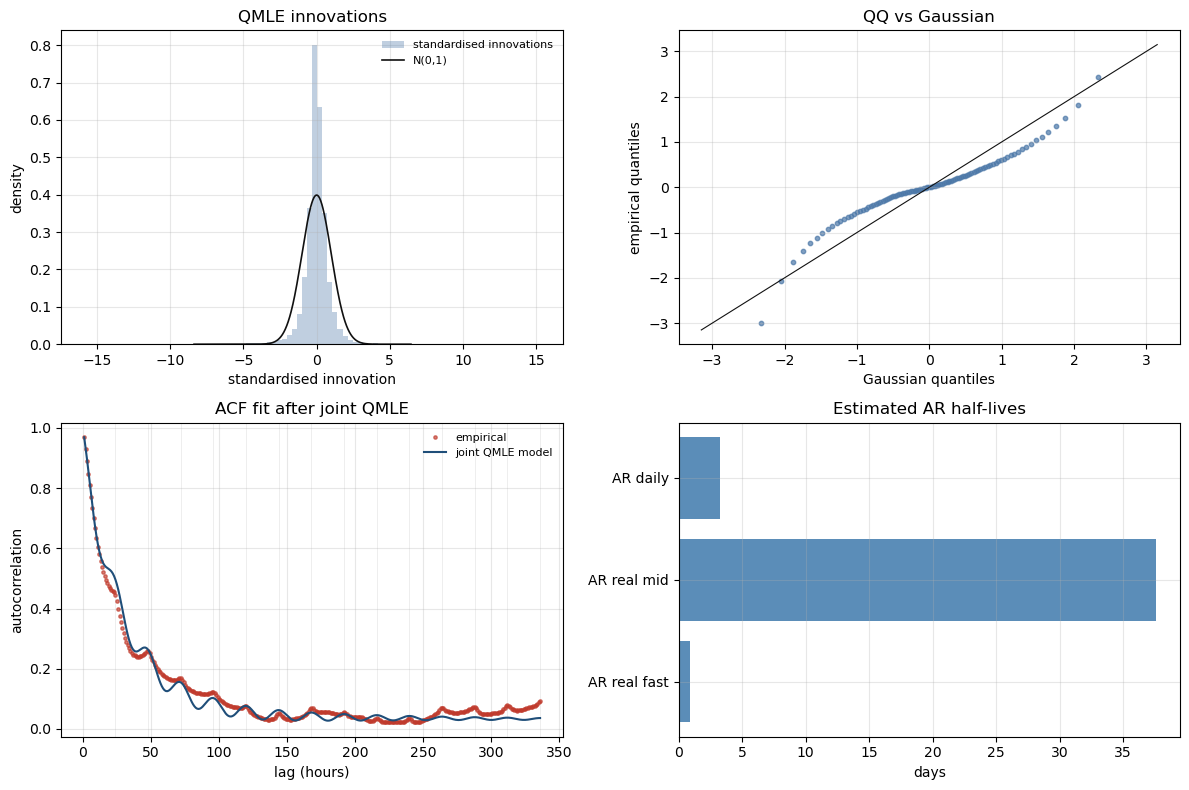

Saved: wind_carma43_joint_qmle_diagnostics.png


In [9]:
rho_model_final = opt["rho_model"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

ax = axes[0, 0]
ax.hist(eps_std, bins=90, density=True, color="#4c78a8", alpha=0.35, label="standardised innovations")
x = np.linspace(np.quantile(eps_std, 0.001), np.quantile(eps_std, 0.999), 600)
ax.plot(x, norm.pdf(x), color="#111111", lw=1.2, label="N(0,1)")
ax.set_title("QMLE innovations")
ax.set_xlabel("standardised innovation")
ax.set_ylabel("density")
ax.legend(frameon=False, fontsize=8)

ax = axes[0, 1]
probs = np.linspace(0.01, 0.99, 99)
emp_q = np.quantile(eps_std, probs)
norm_q = norm.ppf(probs)
lim = max(abs(emp_q).max(), abs(norm_q).max()) * 1.05
ax.scatter(norm_q, emp_q, s=10, color="#4c78a8", alpha=0.7)
ax.plot([-lim, lim], [-lim, lim], color="#111111", lw=0.8)
ax.set_title("QQ vs Gaussian")
ax.set_xlabel("Gaussian quantiles")
ax.set_ylabel("empirical quantiles")

ax = axes[1, 0]
ax.plot(lags_acf, rho_emp_acf, "o", ms=2.4, color="#c0392b", alpha=0.65, label="empirical")
ax.plot(lags_acf, rho_model_final, "-", lw=1.5, color="#1f4e79", label="joint QMLE model")
for hline in range(24, 337, 24):
    ax.axvline(hline, color="#eeeeee", lw=0.7, zorder=0)
ax.set_title("ACF fit after joint QMLE")
ax.set_xlabel("lag (hours)")
ax.set_ylabel("autocorrelation")
ax.legend(frameon=False, fontsize=8)

ax = axes[1, 1]
hl_labels = ["AR real fast", "AR real mid", "AR daily"]
hl_vals = list(ar_half_lives_h) + [ar_complex_half_life_h]
ax.barh(hl_labels, np.asarray(hl_vals) / 24.0, color=["#5b8db8", "#5b8db8", "#5b8db8", "#d28e2f"])
ax.set_title("Estimated AR half-lives")
ax.set_xlabel("days")

plt.tight_layout()
fig_path = FIG / f"wind_{model_tag}_joint_qmle_diagnostics.png"
plt.savefig(fig_path, dpi=130, bbox_inches="tight")
plt.show()
print(f"Saved: {fig_path.name}")


In [10]:
# Final CARMA(4,3) QMLE report: roots, half-lives, periods, and bound status

BOUND_RTOL = 5e-3  # 0.5% tolerance on natural-scale bounds


def bound_status(value, bounds, rtol=BOUND_RTOL):
    lo, hi = map(float, bounds)
    if np.isclose(value, lo, rtol=rtol, atol=1e-8):
        return "LOWER"
    if np.isclose(value, hi, rtol=rtol, atol=1e-8):
        return "UPPER"
    return "interior"


def root_row(label, family, root, hl_bounds=None, omega_bounds=None, fixed=False):
    root = complex(root)
    half_life_h = float(np.log(2.0) / (-root.real))
    omega = float(abs(root.imag))
    period_h = np.nan if omega < 1e-10 else float(2.0 * np.pi / omega)

    if fixed:
        status = "FIXED from 01order"
    else:
        flags = []
        if hl_bounds is not None:
            flags.append(f"HL: {bound_status(half_life_h, hl_bounds)}")
        if omega_bounds is not None:
            flags.append(f"omega: {bound_status(omega, omega_bounds)}")
        status = " | ".join(flags) if flags else "interior"

    return {
        "family": family,
        "component": label,
        "root": (
            f"{root.real:+.6e}"
            if omega < 1e-10
            else f"{root.real:+.6e} ± {omega:.6e}i"
        ),
        "half_life_h": half_life_h,
        "half_life_d": half_life_h / 24.0,
        "omega_h_inv": omega if omega >= 1e-10 else np.nan,
        "period_h": period_h,
        "calibration_status": status,
    }


ar_real, ar_complex_pos = split_real_and_complex_roots(roots_complex)
ma_real, ma_complex_pos = split_real_and_complex_roots(ma_roots_complex)

report = pd.DataFrame([
    root_row("real fast", "AR", ar_real[0], hl_bounds=AR_FAST_BOUNDS_H),
    root_row("real mid", "AR", ar_real[1], hl_bounds=AR_MID_BOUNDS_H),
    root_row(
        "daily complex pair",
        "AR",
        ar_complex_pos[0],
        fixed=True,
    ),
    root_row("real", "MA", ma_real[0], hl_bounds=MA_REAL_BOUNDS_H),
    root_row(
        "complex pair",
        "MA",
        ma_complex_pos[0],
        hl_bounds=MA_COMPLEX_HL_BOUNDS_H,
        omega_bounds=MA_COMPLEX_OMEGA_BOUNDS,
    ),
])

print(f"CARMA({p},{q}) — final QMLE")
print(f"Objective={opt['objective']:.12f} | log-likelihood={qmle['loglik']:.6f}")
print(f"m={m_hat:.6e} | nu²={nu2_hat:.6e} | stationary mean={m_hat * dc_gain:.6e}")
print()

display(
    report.style.format({
        "half_life_h": "{:.3f}",
        "half_life_d": "{:.3f}",
        "omega_h_inv": "{:.6f}",
        "period_h": "{:.3f}",
    }).hide(axis="index")
)

print("\nBounds used (hours)")
print(f"  AR fast: {AR_FAST_BOUNDS_H}")
print(f"  AR mid : {AR_MID_BOUNDS_H}")
print(f"  MA real: {MA_REAL_BOUNDS_H}")
print(f"  MA complex: {MA_COMPLEX_HL_BOUNDS_H}")
print(f"  MA complex omega: {MA_COMPLEX_OMEGA_BOUNDS}")
print("  AR daily pair: fixed from 01order (half-life and 24 h period)")


CARMA(4,3) — final QMLE
Objective=-2.306830313814 | log-likelihood=-6983.727777
m=1.572834e-05 | nu²=9.934486e-02 | stationary mean=8.311635e-04



family,component,root,half_life_h,half_life_d,omega_h_inv,period_h,calibration_status
AR,real fast,-3.313570e-02,20.918,0.872,nan,nan,HL: interior
AR,real mid,-7.680853e-04,902.435,37.601,nan,nan,HL: interior
AR,daily complex pair,-8.796745e-03 ± 2.617994e-01i,78.796,3.283,0.261799,24.000,FIXED from 01order
MA,real,-1.341097e-03,516.851,21.535,nan,nan,HL: interior
MA,complex pair,-2.628858e-02 ± 2.610035e-01i,26.367,1.099,0.261003,24.073,HL: interior | omega: interior



Bounds used (hours)
  AR fast: (0.2, 48.0)
  AR mid : (5.0, 1920.0)
  MA real: (0.2, 720.0)
  MA complex: (0.3, 720.0)
  MA complex omega: (0.0001, 3.141492653589793)
  AR daily pair: fixed from 01order (half-life and 24 h period)


## 3. Recover hourly Levy driver increments

The smoothed CARMA state path is used to recover the hourly driver increments
consistent with the selected CARMA root. These increments are the marginal
weather driver used later by the wind-price coupling notebook.


In [11]:
from scipy.integrate import cumulative_trapezoid

def kalman_filter_state_estimates(A, b_vec, F, Q_base, Pi1, series):
    series = np.asarray(series, dtype=float)
    n = len(series)
    p = A.shape[0]

    x_pred = np.zeros(p)
    P_pred = Pi1.copy()

    pred_states = np.empty((n, p))
    pred_covs = np.empty((n, p, p))
    filt_states = np.empty((n, p))
    filt_covs = np.empty((n, p, p))
    next_pred_states = np.empty((n, p))
    next_pred_covs = np.empty((n, p, p))
    residuals = np.empty(n)
    r_array = np.empty(n)

    for i in range(n):
        pred_states[i] = x_pred
        pred_covs[i] = P_pred

        P_b = P_pred @ b_vec
        Delta_i = float(b_vec @ P_b)
        if Delta_i <= 0:
            raise RuntimeError(f"Delta[{i + 1}]={Delta_i:.6e} <= 0")

        resid = series[i] - float(b_vec @ x_pred)
        gain = P_b / Delta_i
        x_filt = x_pred + gain * resid
        P_filt = P_pred - np.outer(P_b, P_b) / Delta_i
        P_filt = 0.5 * (P_filt + P_filt.T)

        x_next = F @ x_filt
        P_next = F @ P_filt @ F.T + Q_base
        P_next = 0.5 * (P_next + P_next.T)

        residuals[i] = resid
        r_array[i] = Delta_i
        filt_states[i] = x_filt
        filt_covs[i] = P_filt
        next_pred_states[i] = x_next
        next_pred_covs[i] = P_next

        x_pred = x_next
        P_pred = P_next

    return {
        "residuals": residuals,
        "r_array": r_array,
        "pred_states": pred_states,
        "pred_covs": pred_covs,
        "filt_states": filt_states,
        "filt_covs": filt_covs,
        "next_pred_states": next_pred_states,
        "next_pred_covs": next_pred_covs,
    }


def rts_smoother(F, filt_states, filt_covs, next_pred_states, next_pred_covs):
    n, p = filt_states.shape
    smooth_states = filt_states.copy()
    smooth_covs = filt_covs.copy()

    for i in range(n - 2, -1, -1):
        J = np.linalg.solve(next_pred_covs[i].T, (filt_covs[i] @ F.T).T).T
        smooth_states[i] = filt_states[i] + J @ (smooth_states[i + 1] - next_pred_states[i])
        smooth_covs[i] = filt_covs[i] + J @ (smooth_covs[i + 1] - next_pred_covs[i]) @ J.T
        smooth_covs[i] = 0.5 * (smooth_covs[i] + smooth_covs[i].T)

    return smooth_states, smooth_covs


def build_modal_matrix(A, roots_complex):
    roots_complex = np.asarray(roots_complex, dtype=complex)
    p = len(roots_complex)
    E = np.column_stack([lam ** np.arange(p) for lam in roots_complex])
    for r, lam in enumerate(roots_complex):
        err = np.linalg.norm(A @ E[:, r] - lam * E[:, r])
        if err >= 1e-8:
            raise ValueError(f"Eigenvector check failed for root {r}: err={err:.3e}")
    return E, np.linalg.inv(E)


def parse_roots(ar_coeffs, roots=None):
    if roots is None:
        return np.roots(np.concatenate([[1.0], np.asarray(ar_coeffs, dtype=float)]))
    return np.array([r[0] + 1j * r[1] if hasattr(r, "__len__") else complex(r) for r in roots])


def select_recovery_root(roots_complex, tol=1e-8):
    real_mask = np.abs(roots_complex.imag) < tol
    if not np.any(real_mask):
        raise ValueError("No real root available for modal recovery.")
    ridx = np.where(real_mask)[0]
    return int(ridx[np.argmin(np.abs(roots_complex[ridx].real))])


def levy_path_from_states(X_hat, ar_coeffs, b_coeffs, roots=None, Delta=1.0):
    X_hat = np.asarray(X_hat, dtype=float)
    roots_complex = parse_roots(ar_coeffs, roots)
    A_loc = build_companion_matrix(ar_coeffs)
    _, E_inv = build_modal_matrix(A_loc, roots_complex)

    idx_r = select_recovery_root(roots_complex)
    lam_r = float(roots_complex[idx_r].real)

    b_lam = float(sum(c * lam_r ** k for k, c in enumerate(b_coeffs)))
    xi_r = (E_inv @ X_hat.T)[idx_r]
    imag_frac = np.abs(xi_r.imag).max() / (np.abs(xi_r.real).max() + 1e-30)
    if imag_frac > 1e-6:
        raise ValueError(f"Imaginary residual too large in modal coordinate: {imag_frac:.2e}")

    Y_r = b_lam * xi_r.real
    a_desc = np.concatenate([[1.0], np.asarray(ar_coeffs, dtype=float)])
    a_prime = float(np.polyval(np.polyder(a_desc), lam_r))
    alpha_r = b_lam / a_prime

    times = np.arange(len(Y_r)) * Delta
    integ = cumulative_trapezoid(Y_r, times, initial=0.0)
    L_hat = (Y_r - Y_r[0] - lam_r * integ) / alpha_r

    return {
        "L_hat": L_hat,
        "increments": np.diff(L_hat),
        "Y_r": Y_r,
        "lambda_r": lam_r,
        "idx_r": idx_r,
        "alpha_r": float(alpha_r),
    }


def recover_levy_increments(y, ar_coeffs, b_coeffs, m_hat, nu2_hat, roots=None, Delta=1.0):
    y = np.asarray(y, dtype=float)
    p = len(ar_coeffs)
    A_loc = build_companion_matrix(ar_coeffs)
    ep_loc = np.zeros(p)
    ep_loc[-1] = 1.0
    b_loc = build_b_vector(b_coeffs, p)
    F_loc = expm(A_loc * Delta)
    Pi1_loc = solve_continuous_lyapunov(A_loc, -np.outer(ep_loc, ep_loc))
    Qb_loc = discrete_noise_covariance(A_loc, ep_loc, Delta)
    dc = float(b_coeffs[0] / ar_coeffs[-1])

    W = y - m_hat * dc
    filt = kalman_filter_state_estimates(A_loc, b_loc, F_loc, Qb_loc, Pi1_loc, W)
    U_smooth, _ = rts_smoother(
        F_loc,
        filt["filt_states"],
        filt["filt_covs"],
        filt["next_pred_states"],
        filt["next_pred_covs"],
    )

    obs_resid = W - U_smooth @ b_loc
    shift = np.linalg.solve(-A_loc, ep_loc)
    X_hat = U_smooth + m_hat * shift

    out = levy_path_from_states(X_hat, ar_coeffs, b_coeffs, roots=roots, Delta=Delta)
    out["state_path"] = X_hat
    out["obs_resid_max"] = float(np.max(np.abs(obs_resid)))
    out["nu2_hat"] = float(nu2_hat)
    out["m_hat"] = float(m_hat)
    return out


levy_out = recover_levy_increments(
    pr,
    ar_coefficients,
    b_coefficients,
    m_hat=m_hat,
    nu2_hat=nu2_hat,
    roots=roots,
    Delta=Delta,
)

L_hat = levy_out["L_hat"]
driver_delta_l = levy_out["increments"]

levy_npz_path = OUT / f"wind_{model_tag}_levy_increments_recovered.npz"
np.savez(
    levy_npz_path,
    L_hat=L_hat,
    increments=driver_delta_l,
    Y_r=levy_out["Y_r"],
    lambda_r=np.array([levy_out["lambda_r"]]),
    idx_r=np.array([levy_out["idx_r"]], dtype=int),
    alpha_r=np.array([levy_out["alpha_r"]]),
    nu2_hat=np.array([nu2_hat]),
    m_hat=np.array([m_hat]),
    obs_resid_max=np.array([levy_out["obs_resid_max"]]),
)

recovery_half_life_h = np.log(2.0) / (-levy_out["lambda_r"])
print(f"Selected recovery root lambda = {levy_out['lambda_r']:.6e}")
print(f"Selected recovery root half-life = {recovery_half_life_h:.3f} h = {recovery_half_life_h / 24.0:.3f} d")
print(f"Recovered Delta L mean/std    = {driver_delta_l.mean():.6e} / {driver_delta_l.std(ddof=0):.6e}")
print(f"Recovered Delta L var / nu2   = {np.var(driver_delta_l) / nu2_hat:.6f}")
print(f"Max smoother observation residual = {levy_out['obs_resid_max']:.3e}")
print(f"Saved: {levy_npz_path.name}")


Selected recovery root lambda = -7.680853e-04
Selected recovery root half-life = 902.435 h = 37.601 d
Recovered Delta L mean/std    = -2.783967e-04 / 3.151694e-01
Recovered Delta L var / nu2   = 0.999868
Max smoother observation residual = 1.199e-14
Saved: wind_carma43_levy_increments_recovered.npz


## 4. Fit Gaussian and NIG laws to recovered `Delta L`


In [12]:
def log_nig_pdf_save03(x, mu, delta, alpha, beta):
    x = np.asarray(x, dtype=float)
    gamma = np.sqrt(alpha * alpha - beta * beta)
    xm = x - mu
    r = np.sqrt(delta * delta + xm * xm)
    return (
        np.log(alpha * delta / np.pi)
        + delta * gamma
        + beta * xm
        + np.log(kve(1, alpha * r))
        - alpha * r
        - np.log(r)
    )


def fit_nig_manual(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    mu_g = float(x.mean())
    sig_g = float(x.std(ddof=1))
    kurt_raw = float(np.mean((x - mu_g) ** 4) / sig_g ** 4)
    skew_raw = float(np.mean((x - mu_g) ** 3) / sig_g ** 3)

    alpha0 = np.sqrt(3.0 / (sig_g ** 2 * max(kurt_raw - 3.0, 0.01)))
    delta0 = sig_g ** 2 * alpha0
    beta0 = np.clip(
        skew_raw * alpha0 * np.sqrt(delta0 * alpha0) / 3.0,
        -0.9 * alpha0,
        0.9 * alpha0,
    )

    def pack(mu, delta, alpha, beta):
        return np.array([mu, np.log(delta), np.log(alpha), np.arctanh(beta / (0.99 * alpha))])

    def unpack(theta):
        mu = theta[0]
        delta = np.exp(theta[1])
        alpha = np.exp(theta[2])
        beta = np.tanh(theta[3]) * 0.99 * alpha
        return mu, delta, alpha, beta

    def nll(theta):
        mu, delta, alpha, beta = unpack(theta)
        ll = log_nig_pdf_save03(x, mu, delta, alpha, beta)
        if not np.all(np.isfinite(ll)):
            return 1e50
        return -float(ll.sum())

    theta0 = pack(mu_g, delta0, alpha0, beta0)
    best = None
    for beta_shift in np.linspace(-0.5, 0.5, 5):
        res = minimize(nll, theta0 + np.array([0.0, 0.0, 0.0, beta_shift]),
                       method="L-BFGS-B", options={"maxiter": 800, "ftol": 1e-10})
        if best is None or res.fun < best.fun:
            best = res

    mu, delta, alpha, beta = unpack(best.x)
    gamma = np.sqrt(alpha * alpha - beta * beta)
    return {
        "mu": float(mu),
        "delta": float(delta),
        "alpha": float(alpha),
        "beta": float(beta),
        "gamma": float(gamma),
        "scipy_a": float(alpha * delta),
        "scipy_b": float(beta * delta),
        "scipy_loc": float(mu),
        "scipy_scale": float(delta),
        "loglik": float(-best.fun),
        "mean": float(mu + delta * beta / gamma),
        "variance": float(delta * alpha * alpha / gamma ** 3),
        "std": float(np.sqrt(delta * alpha * alpha / gamma ** 3)),
        "skew": float(3 * beta / (alpha * np.sqrt(delta * gamma))),
        "excess_kurtosis": float(3 * (1 + 4 * beta * beta / (alpha * alpha)) / (delta * gamma)),
        "success": bool(best.success),
        "message": str(best.message),
        "N": int(len(x)),
    }


dL = np.asarray(driver_delta_l, dtype=float)
gaussian_driver = {
    "mean": float(dL.mean()),
    "variance": float(dL.var(ddof=0)),
    "std": float(dL.std(ddof=0)),
    "m_rate": float(dL.mean() / Delta),
    "nu2_rate": float(dL.var(ddof=0) / Delta),
    "N": int(len(dL)),
}
nig_driver = fit_nig_manual(dL)

driver_fits = {
    "gaussian": gaussian_driver,
    "nig": nig_driver,
    "source": "recovered hourly Levy increments from wind/02mle_wind.ipynb",
}
driver_fits_path = OUT / f"wind_{model_tag}_driver_fits.json"
driver_fits_path.write_text(json.dumps(driver_fits, indent=2))

print("Gaussian driver fit on Delta L")
print(f"  mean/std = {gaussian_driver['mean']:.6e} / {gaussian_driver['std']:.6e}")
print("NIG driver fit on Delta L")
print(f"  mu,delta,alpha,beta = {nig_driver['mu']:.6e}, {nig_driver['delta']:.6e}, {nig_driver['alpha']:.6e}, {nig_driver['beta']:.6e}")
print(f"  mean/std            = {nig_driver['mean']:.6e} / {nig_driver['std']:.6e}")
print(f"  skew/kurt           = {nig_driver['skew']:.4f} / {nig_driver['excess_kurtosis']:.4f}")
print(f"Saved: {driver_fits_path.name}")


Gaussian driver fit on Delta L
  mean/std = -2.783967e-04 / 3.151694e-01
NIG driver fit on Delta L
  mu,delta,alpha,beta = 7.067544e-03, 1.321784e-01, 1.533910e+00, -8.511714e-02
  mean/std            = -2.783940e-04 / 2.942285e-01
  skew/kurt           = -0.3700 / 15.0019
Saved: wind_carma43_driver_fits.json


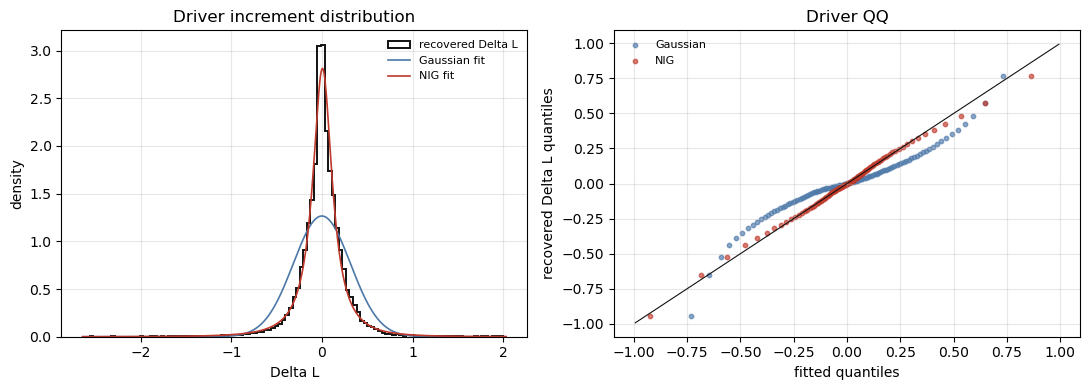

Saved: wind_carma43_driver_deltaL_fits.png


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
probs = np.linspace(0.01, 0.99, 99)

ax = axes[0]
bins = np.linspace(np.quantile(dL, 0.001), np.quantile(dL, 0.999), 120)
x = np.linspace(bins[0], bins[-1], 700)
ax.hist(dL, bins=bins, density=True, histtype="step", color="#111111", lw=1.4, label="recovered Delta L")
ax.plot(x, norm.pdf(x, gaussian_driver["mean"], gaussian_driver["std"]),
        color="#4c78a8", lw=1.2, label="Gaussian fit")
ax.plot(x, norminvgauss.pdf(x, nig_driver["scipy_a"], nig_driver["scipy_b"],
                            loc=nig_driver["scipy_loc"], scale=nig_driver["scipy_scale"]),
        color="#c0392b", lw=1.2, label="NIG fit")
ax.set_title("Driver increment distribution")
ax.set_xlabel("Delta L")
ax.set_ylabel("density")
ax.legend(frameon=False, fontsize=8)

ax = axes[1]
obs_q = np.quantile(dL, probs)
gauss_q = norm.ppf(probs, gaussian_driver["mean"], gaussian_driver["std"])
nig_q = norminvgauss.ppf(probs, nig_driver["scipy_a"], nig_driver["scipy_b"],
                         loc=nig_driver["scipy_loc"], scale=nig_driver["scipy_scale"])
lim = max(abs(obs_q).max(), abs(gauss_q).max(), abs(nig_q).max()) * 1.05
ax.scatter(gauss_q, obs_q, s=10, color="#4c78a8", alpha=0.65, label="Gaussian")
ax.scatter(nig_q, obs_q, s=10, color="#c0392b", alpha=0.65, label="NIG")
ax.plot([-lim, lim], [-lim, lim], color="#111111", lw=0.8)
ax.set_title("Driver QQ")
ax.set_xlabel("fitted quantiles")
ax.set_ylabel("recovered Delta L quantiles")
ax.legend(frameon=False, fontsize=8)

plt.tight_layout()
fig_path = FIG / f"wind_{model_tag}_driver_deltaL_fits.png"
plt.savefig(fig_path, dpi=130, bbox_inches="tight")
plt.show()
print(f"Saved: {fig_path.name}")


## 5. Simulate selected wind CARMA model with fitted drivers


In [14]:
def simulate_gaussian_carma_exact(A, b_vec, F, Q_base, Pi1, ep, driver_fit,
                                  n_steps, n_paths, seed=20260621):
    rng = np.random.default_rng(seed)
    p = A.shape[0]
    m_rate = driver_fit["m_rate"]
    nu2_rate = driver_fit["nu2_rate"]

    state_mean = m_rate * np.linalg.solve(-A, ep)
    pi_sqrt = psd_sqrt(Pi1)
    q_sqrt = psd_sqrt(Q_base)
    g = np.linalg.solve(A, (F - np.eye(p)) @ ep)

    X = state_mean + np.sqrt(nu2_rate) * (rng.standard_normal((n_paths, p)) @ pi_sqrt.T)
    Y = np.empty((n_paths, n_steps))

    for t in range(n_steps):
        shocks = np.sqrt(nu2_rate) * (rng.standard_normal((n_paths, p)) @ q_sqrt.T)
        X = X @ F.T + m_rate * g + shocks
        Y[:, t] = X @ b_vec

    return Y


def simulate_nig_carma_midpoint(A, b_vec, F, ep, nig_fit,
                                n_steps, n_paths, burnin=5000, seed=20260622):
    rng = np.random.default_rng(seed)
    p = A.shape[0]
    shock_vec = expm(A * 0.5) @ ep
    mean_dL = nig_fit["mean"]
    state_mean = np.linalg.solve(np.eye(p) - F, shock_vec * mean_dL)

    X = np.tile(state_mean, (n_paths, 1))
    Y = np.empty((n_paths, n_steps))

    dL_all = norminvgauss.rvs(
        nig_fit["scipy_a"],
        nig_fit["scipy_b"],
        loc=nig_fit["scipy_loc"],
        scale=nig_fit["scipy_scale"],
        size=(n_paths, n_steps + burnin),
        random_state=rng,
    )

    out_i = 0
    for t in range(n_steps + burnin):
        X = X @ F.T + dL_all[:, t, None] * shock_vec
        if t >= burnin:
            Y[:, out_i] = X @ b_vec
            out_i += 1

    return Y, dL_all[:, burnin:]


N_PATHS = 250
gaussian_paths = simulate_gaussian_carma_exact(
    A, b_vec, F, Q_base, Pi1, ep, gaussian_driver,
    n_steps=N, n_paths=N_PATHS, seed=20260621,
)
nig_paths, nig_driver_draws = simulate_nig_carma_midpoint(
    A, b_vec, F, ep, nig_driver,
    n_steps=N, n_paths=N_PATHS, burnin=5000, seed=20260622,
)

gaussian_delta_y = np.diff(gaussian_paths, axis=1)
nig_delta_y = np.diff(nig_paths, axis=1)

print(f"Gaussian exact CARMA paths: {gaussian_paths.shape}")
print(f"NIG midpoint CARMA paths  : {nig_paths.shape}")
print(f"Gaussian Y mean/std       : {gaussian_paths.mean():.6e} / {gaussian_paths.std(ddof=0):.6e}")
print(f"NIG Y mean/std            : {nig_paths.mean():.6e} / {nig_paths.std(ddof=0):.6e}")
print(f"Observed Y mean/std       : {pr.mean():.6e} / {pr.std(ddof=0):.6e}")


Gaussian exact CARMA paths: (250, 26305)
NIG midpoint CARMA paths  : (250, 26305)
Gaussian Y mean/std       : -1.277115e-02 / 1.295889e+00
NIG Y mean/std            : -8.209566e-03 / 1.209103e+00
Observed Y mean/std       : 2.057211e-15 / 1.299078e+00


In [15]:
summary = pd.DataFrame({
    "observed_XtQ": distribution_summary(pr),
    "gaussian_CARMA_XtQ": distribution_summary(gaussian_paths),
    "nig_CARMA_XtQ": distribution_summary(nig_paths),
    "observed_Delta_XtQ": distribution_summary(obs_delta_y),
    "gaussian_CARMA_Delta_XtQ": distribution_summary(gaussian_delta_y),
    "nig_CARMA_Delta_XtQ": distribution_summary(nig_delta_y),
    "recovered_DeltaL": distribution_summary(driver_delta_l),
    "nig_simulated_DeltaL": distribution_summary(nig_driver_draws),
}).T

summary_path = OUT / f"wind_{model_tag}_distribution_summary.csv"
summary.to_csv(summary_path)
print(summary.to_string(float_format=lambda v: f"{v:.6e}"))
print(f"\nSaved: {summary_path}")


                                  mean          std           q01           q05        median          q95          q99          skew  excess_kurtosis
observed_XtQ              2.057211e-15 1.299078e+00 -4.012610e+00 -2.168519e+00  6.449153e-02 1.933454e+00 2.581593e+00 -9.331607e-01     3.068512e+00
gaussian_CARMA_XtQ       -1.277115e-02 1.295889e+00 -3.029172e+00 -2.144530e+00 -1.242774e-02 2.115859e+00 3.003866e+00 -1.239457e-03     5.221087e-03
nig_CARMA_XtQ            -8.209566e-03 1.209103e+00 -2.985645e+00 -2.001334e+00  3.863918e-03 1.948377e+00 2.861052e+00 -6.582395e-02     5.048144e-01
observed_Delta_XtQ       -1.075522e-04 3.213466e-01 -9.188664e-01 -3.837852e-01 -3.365279e-03 4.050261e-01 8.327050e-01 -8.910206e-01     3.834242e+01
gaussian_CARMA_Delta_XtQ -4.974754e-06 3.231853e-01 -7.524952e-01 -5.314709e-01  1.416622e-05 5.318194e-01 7.519098e-01 -1.923991e-04     2.391686e-03
nig_CARMA_Delta_XtQ       1.114766e-06 3.016460e-01 -9.315774e-01 -4.332979e-01  4.125198e-03 

In [16]:
max_lag = 336
lags = np.arange(max_lag + 1)
acf_obs = acf_1d(pr, max_lag)
acf_gaussian = np.mean([acf_1d(path, max_lag) for path in gaussian_paths], axis=0)
acf_nig = np.mean([acf_1d(path, max_lag) for path in nig_paths], axis=0)

acf_diag_lags = [1, 2, 3, 6, 12, 24, 48, 72, 168, 336]
acf_table = pd.DataFrame({
    "lag": acf_diag_lags,
    "observed": acf_obs[acf_diag_lags],
    "gaussian_CARMA": acf_gaussian[acf_diag_lags],
    "nig_CARMA": acf_nig[acf_diag_lags],
})
print(acf_table.to_string(index=False, float_format=lambda v: f"{v:.6f}"))


 lag  observed  gaussian_CARMA  nig_CARMA
   1  0.969355        0.968604   0.968561
   2  0.929354        0.934256   0.934196
   3  0.888490        0.897390   0.897329
   6  0.771563        0.779238   0.779132
  12  0.579915        0.589252   0.588749
  24  0.444893        0.490962   0.492066
  48  0.257976        0.256510   0.258248
  72  0.168016        0.145749   0.149473
 168  0.069795        0.046189   0.048887
 336  0.090787        0.028834   0.029834


## 6. Posterior predictive checks on wind residual `XtQ`


In [17]:
PPC_LAGS = [1, 6, 24, 72, 168, 336]


def acf_selected_lags(x, lags):
    x = np.asarray(x, dtype=float)
    x = x - x.mean()
    denom = float(np.dot(x, x))
    vals = []
    for lag in lags:
        if lag <= 0:
            vals.append(1.0)
        elif lag >= len(x) or denom <= 0.0:
            vals.append(np.nan)
        else:
            vals.append(float(np.dot(x[:-lag], x[lag:]) / denom))
    return np.array(vals, dtype=float)


def skew_and_excess_kurtosis(x):
    x = np.asarray(x, dtype=float)
    z = x - x.mean()
    sd = z.std(ddof=0)
    if sd <= 0.0:
        return np.nan, np.nan
    z = z / sd
    return float(np.mean(z ** 3)), float(np.mean(z ** 4) - 3.0)


def path_ppc_stats(y, lags=PPC_LAGS):
    y = np.asarray(y, dtype=float)
    dy = np.diff(y)
    skew_y, kurt_y = skew_and_excess_kurtosis(y)
    _, kurt_dy = skew_and_excess_kurtosis(dy)

    out = {
        "XtQ_std": float(np.std(y, ddof=0)),
        "XtQ_skew": skew_y,
        "XtQ_excess_kurtosis": kurt_y,
        "XtQ_q01": float(np.quantile(y, 0.01)),
        "XtQ_q05": float(np.quantile(y, 0.05)),
        "XtQ_q95": float(np.quantile(y, 0.95)),
        "XtQ_q99": float(np.quantile(y, 0.99)),
        "Delta_XtQ_std": float(np.std(dy, ddof=0)),
        "Delta_XtQ_excess_kurtosis": kurt_dy,
        "Delta_XtQ_q01": float(np.quantile(dy, 0.01)),
        "Delta_XtQ_q99": float(np.quantile(dy, 0.99)),
    }

    acf_y = acf_selected_lags(y, lags)
    acf_dy = acf_selected_lags(dy, lags)
    for lag, val in zip(lags, acf_y):
        out[f"ACF_XtQ_{lag}h"] = float(val)
    for lag, val in zip(lags, acf_dy):
        out[f"ACF_DeltaXtQ_{lag}h"] = float(val)
    return pd.Series(out)


def simulated_ppc_stats(paths, lags=PPC_LAGS):
    rows = [path_ppc_stats(path, lags=lags) for path in np.asarray(paths)]
    return pd.DataFrame(rows)


def posterior_predictive_table(observed_stats, simulated_stats, model):
    rows = []
    for metric, observed in observed_stats.items():
        sims = simulated_stats[metric].dropna().to_numpy(float)
        q025, q50, q975 = np.quantile(sims, [0.025, 0.50, 0.975])
        obs_percentile = float(np.mean(sims <= observed))
        two_sided_p = float(min(1.0, 2.0 * min(obs_percentile, 1.0 - obs_percentile)))
        rows.append({
            "model": model,
            "metric": metric,
            "observed": float(observed),
            "sim_mean": float(np.mean(sims)),
            "sim_sd": float(np.std(sims, ddof=1)),
            "sim_q025": float(q025),
            "sim_q50": float(q50),
            "sim_q975": float(q975),
            "obs_percentile": obs_percentile,
            "two_sided_p": two_sided_p,
            "inside_95": bool(q025 <= observed <= q975),
            "n_paths": int(len(sims)),
        })
    return pd.DataFrame(rows)


observed_ppc = path_ppc_stats(pr)
gaussian_ppc_paths = simulated_ppc_stats(gaussian_paths)
nig_ppc_paths = simulated_ppc_stats(nig_paths)

ppc_table = pd.concat([
    posterior_predictive_table(observed_ppc, gaussian_ppc_paths, "Gaussian CARMA"),
    posterior_predictive_table(observed_ppc, nig_ppc_paths, "NIG CARMA"),
], ignore_index=True)

ppc_path = OUT / f"wind_{model_tag}_posterior_predictive_checks.csv"
ppc_table.to_csv(ppc_path, index=False)

display_cols = [
    "metric",
    "observed",
    "sim_mean",
    "sim_q025",
    "sim_q975",
    "obs_percentile",
    "two_sided_p",
    "inside_95",
]

print("NIG CARMA posterior predictive checks")
print(
    ppc_table.loc[ppc_table["model"] == "NIG CARMA", display_cols]
    .to_string(index=False, float_format=lambda v: f"{v:.6e}")
)

print("\nMetrics outside the 95% posterior predictive envelope")
outliers = ppc_table.loc[~ppc_table["inside_95"], ["model"] + display_cols]
if len(outliers) == 0:
    print("None")
else:
    print(outliers.to_string(index=False, float_format=lambda v: f"{v:.6e}"))

print(f"\nSaved: {ppc_path}")


NIG CARMA posterior predictive checks
                   metric      observed      sim_mean      sim_q025      sim_q975  obs_percentile  two_sided_p  inside_95
                  XtQ_std  1.299078e+00  1.204672e+00  1.136212e+00  1.273345e+00    1.000000e+00 0.000000e+00      False
                 XtQ_skew -9.331075e-01 -6.570958e-02 -2.322046e-01  1.142307e-01    0.000000e+00 0.000000e+00      False
      XtQ_excess_kurtosis  3.067701e+00  4.948339e-01  1.144975e-01  9.941361e-01    1.000000e+00 0.000000e+00      False
                  XtQ_q01 -4.012610e+00 -2.974155e+00 -3.339623e+00 -2.680270e+00    0.000000e+00 0.000000e+00      False
                  XtQ_q05 -2.168519e+00 -1.996524e+00 -2.243019e+00 -1.757339e+00    7.600000e-02 1.520000e-01       True
                  XtQ_q95  1.933454e+00  1.941327e+00  1.705545e+00  2.187788e+00    4.640000e-01 9.280000e-01       True
                  XtQ_q99  2.581593e+00  2.850783e+00  2.556849e+00  3.197076e+00    3.600000e-02 7.200000e-

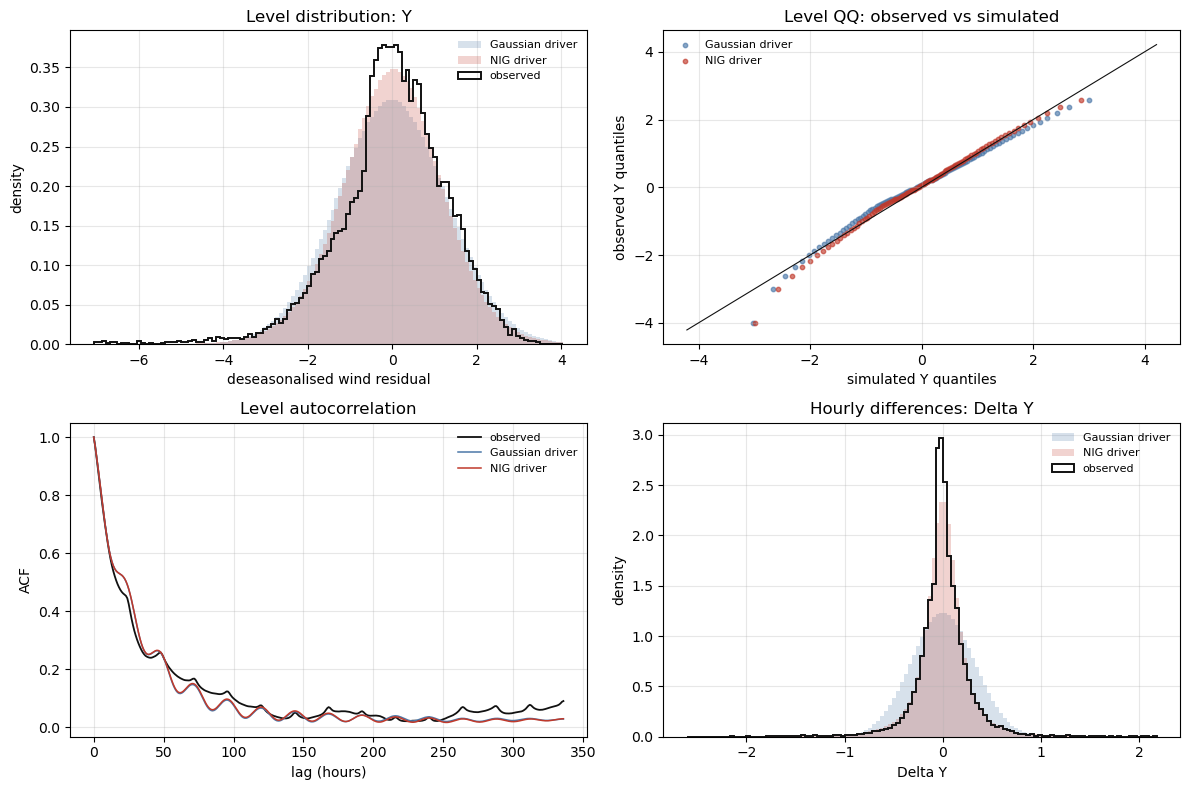

Saved: wind_carma43_level_distribution_comparison.png


In [18]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
probs = np.linspace(0.01, 0.99, 99)

ax = axes[0, 0]
bins_y = np.linspace(
    min(np.quantile(pr, 0.001), np.quantile(gaussian_paths, 0.001), np.quantile(nig_paths, 0.001)),
    max(np.quantile(pr, 0.999), np.quantile(gaussian_paths, 0.999), np.quantile(nig_paths, 0.999)),
    120,
)
ax.hist(gaussian_paths.ravel(), bins=bins_y, density=True, color="#4c78a8", alpha=0.22, label="Gaussian driver")
ax.hist(nig_paths.ravel(), bins=bins_y, density=True, color="#c0392b", alpha=0.22, label="NIG driver")
ax.hist(pr, bins=bins_y, density=True, histtype="step", color="#111111", lw=1.4, label="observed")
ax.set_title("Level distribution: Y")
ax.set_xlabel("deseasonalised wind residual")
ax.set_ylabel("density")
ax.legend(frameon=False, fontsize=8)

ax = axes[0, 1]
obs_q = np.quantile(pr, probs)
gauss_q = np.quantile(gaussian_paths.ravel(), probs)
nig_q = np.quantile(nig_paths.ravel(), probs)
lim = max(abs(obs_q).max(), abs(gauss_q).max(), abs(nig_q).max()) * 1.05
ax.scatter(gauss_q, obs_q, s=10, color="#4c78a8", alpha=0.65, label="Gaussian driver")
ax.scatter(nig_q, obs_q, s=10, color="#c0392b", alpha=0.65, label="NIG driver")
ax.plot([-lim, lim], [-lim, lim], color="#111111", lw=0.8)
ax.set_title("Level QQ: observed vs simulated")
ax.set_xlabel("simulated Y quantiles")
ax.set_ylabel("observed Y quantiles")
ax.legend(frameon=False, fontsize=8)

ax = axes[1, 0]
ax.plot(lags, acf_obs, color="#111111", lw=1.3, label="observed")
ax.plot(lags, acf_gaussian, color="#4c78a8", lw=1.1, label="Gaussian driver")
ax.plot(lags, acf_nig, color="#c0392b", lw=1.1, label="NIG driver")
ax.set_title("Level autocorrelation")
ax.set_xlabel("lag (hours)")
ax.set_ylabel("ACF")
ax.legend(frameon=False, fontsize=8)

ax = axes[1, 1]
bins_dy = np.linspace(
    min(np.quantile(obs_delta_y, 0.001), np.quantile(gaussian_delta_y, 0.001), np.quantile(nig_delta_y, 0.001)),
    max(np.quantile(obs_delta_y, 0.999), np.quantile(gaussian_delta_y, 0.999), np.quantile(nig_delta_y, 0.999)),
    120,
)
ax.hist(gaussian_delta_y.ravel(), bins=bins_dy, density=True, color="#4c78a8", alpha=0.22, label="Gaussian driver")
ax.hist(nig_delta_y.ravel(), bins=bins_dy, density=True, color="#c0392b", alpha=0.22, label="NIG driver")
ax.hist(obs_delta_y, bins=bins_dy, density=True, histtype="step", color="#111111", lw=1.4, label="observed")
ax.set_title("Hourly differences: Delta Y")
ax.set_xlabel("Delta Y")
ax.set_ylabel("density")
ax.legend(frameon=False, fontsize=8)

plt.tight_layout()
fig_path = FIG / f"wind_{model_tag}_level_distribution_comparison.png"
plt.savefig(fig_path, dpi=130, bbox_inches="tight")
plt.show()
print(f"Saved: {fig_path.name}")


## 7. Final residual and physical wind checks

The latent CARMA residual simulations are mapped back to wind levels by
adding the deterministic Fourier seasonality from the Germany seasonality
notebook. This gives checks both in residual coordinates and in physical degrees
logit capacity-factor units.


                       mean          std           q01           q05        median          q95          q99          skew  excess_kurtosis    delta_std     delta_q01    delta_q99
observed_XtQ   2.057211e-15 1.299078e+00 -4.012610e+00 -2.168519e+00  6.449153e-02 1.933454e+00 2.581593e+00 -9.331075e-01     3.067701e+00 3.213466e-01 -9.188664e-01 8.327050e-01
gaussian_XtQ  -1.277115e-02 1.295889e+00 -3.029172e+00 -2.144530e+00 -1.242774e-02 2.115859e+00 3.003866e+00 -1.239457e-03     5.220171e-03 3.233482e-01 -7.526297e-01 7.520582e-01
nig_XtQ       -8.209566e-03 1.209103e+00 -2.985645e+00 -2.001334e+00  3.863918e-03 1.948377e+00 2.861052e+00 -6.582394e-02     5.048131e-01 3.018457e-01 -9.319758e-01 8.720359e-01
observed_wind -1.688733e+00 1.380457e+00 -5.804823e+00 -3.999220e+00 -1.546447e+00 4.494144e-01 1.195908e+00 -8.474052e-01     2.901809e+00 3.251101e-01 -9.534036e-01 8.550625e-01
gaussian_wind -1.701504e+00 1.378010e+00 -4.893265e+00 -3.963938e+00 -1.703984e+00 5.681218e-01 1.51

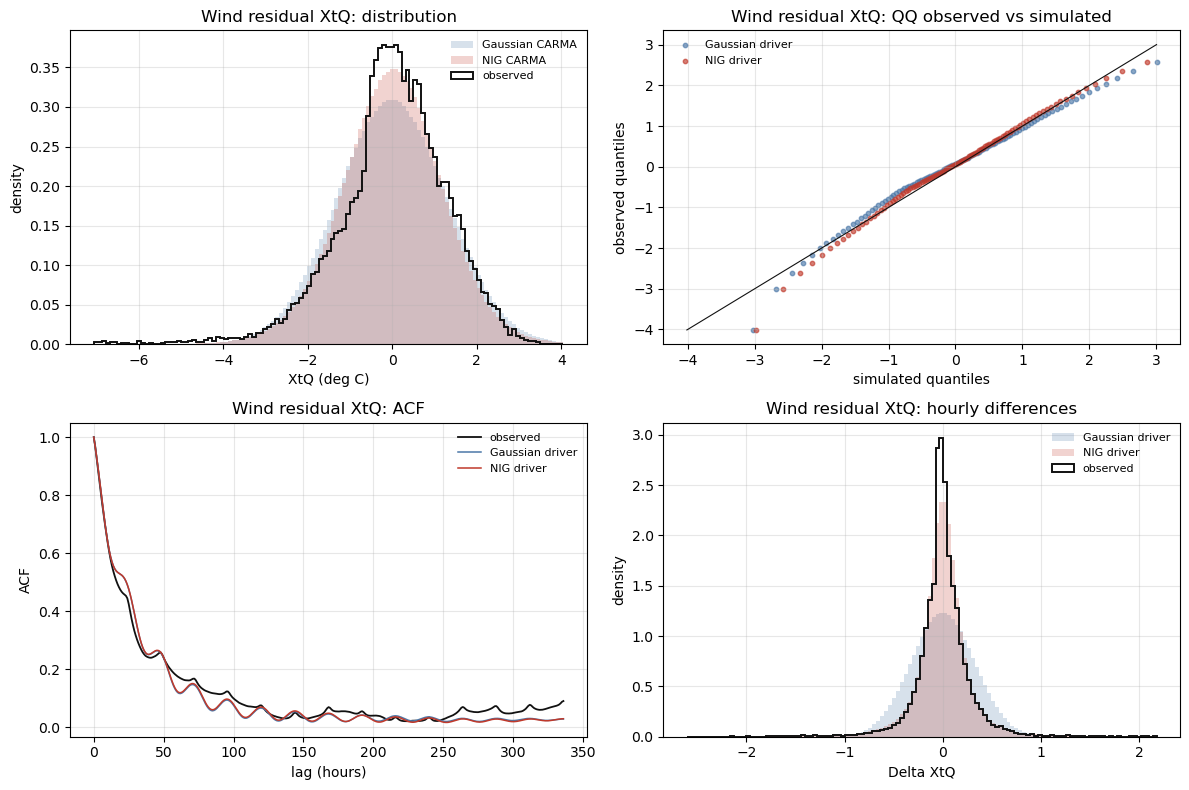

Saved: wind_carma43_final_latent_comparison.png


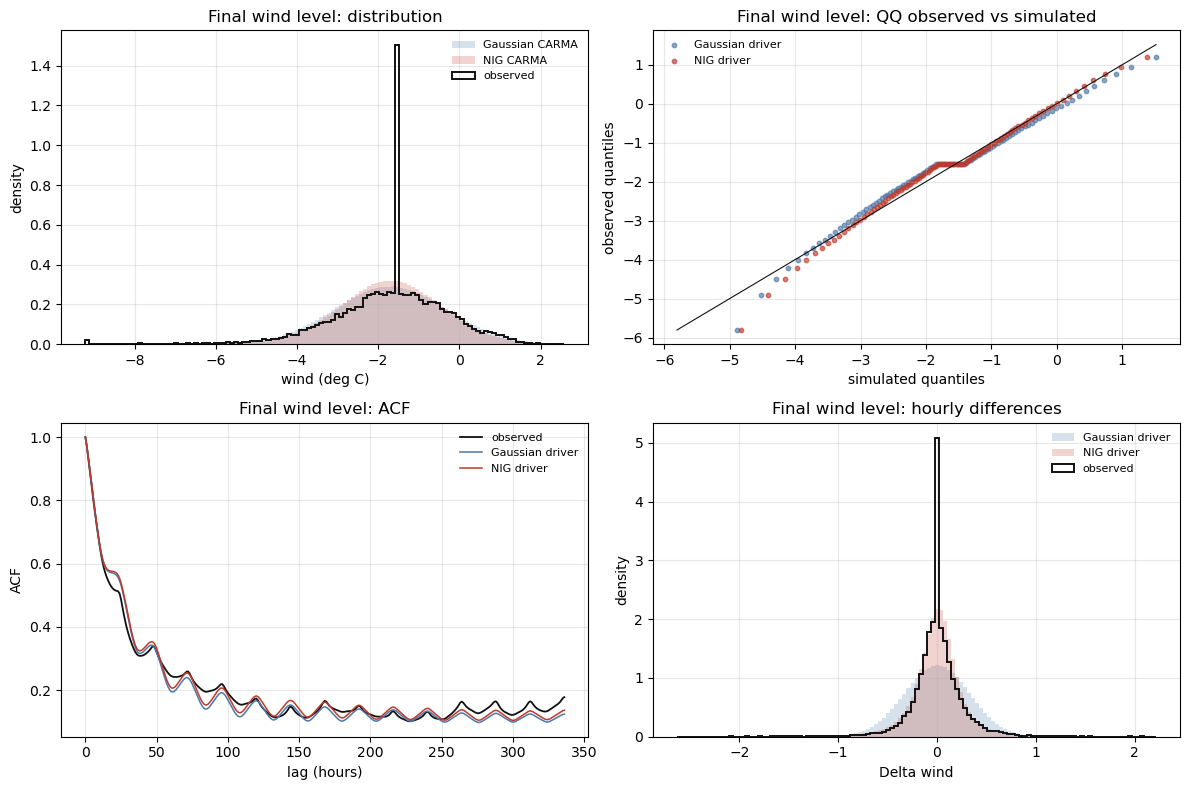

Saved: wind_carma43_final_wind_comparison.png


In [19]:
def final_distribution_summary(x):
    x = np.asarray(x, dtype=float).ravel()
    x = x[np.isfinite(x)]
    dx = np.diff(x)
    z = x - x.mean()
    sd = z.std(ddof=0)
    skew = float(np.mean((z / sd) ** 3)) if sd > 0 else np.nan
    kurt = float(np.mean((z / sd) ** 4) - 3.0) if sd > 0 else np.nan
    return pd.Series({
        "mean": float(np.mean(x)),
        "std": float(np.std(x, ddof=0)),
        "q01": float(np.quantile(x, 0.01)),
        "q05": float(np.quantile(x, 0.05)),
        "median": float(np.quantile(x, 0.50)),
        "q95": float(np.quantile(x, 0.95)),
        "q99": float(np.quantile(x, 0.99)),
        "skew": skew,
        "excess_kurtosis": kurt,
        "delta_std": float(np.std(dx, ddof=0)),
        "delta_q01": float(np.quantile(dx, 0.01)),
        "delta_q99": float(np.quantile(dx, 0.99)),
    })


def residual_paths_to_wind(latent_residual_paths):
    latent_residual_paths = np.asarray(latent_residual_paths, dtype=float)
    n_steps = latent_residual_paths.shape[1]
    seasonal = wind_seasonal[:n_steps]
    return seasonal[None, :] + latent_residual_paths


def plot_final_wind_cfhecks(observed, gaussian_sim, nig_sim, observed_delta, gaussian_delta, nig_delta,
                                  acf_max_lag, title_prefix, xlabel, delta_xlabel, fig_path):
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    probs = np.linspace(0.01, 0.99, 99)

    ax = axes[0, 0]
    bins = np.linspace(
        min(np.quantile(observed, 0.001), np.quantile(gaussian_sim, 0.001), np.quantile(nig_sim, 0.001)),
        max(np.quantile(observed, 0.999), np.quantile(gaussian_sim, 0.999), np.quantile(nig_sim, 0.999)),
        120,
    )
    ax.hist(gaussian_sim.ravel(), bins=bins, density=True, color="#4c78a8", alpha=0.22, label="Gaussian CARMA")
    ax.hist(nig_sim.ravel(), bins=bins, density=True, color="#c0392b", alpha=0.22, label="NIG CARMA")
    ax.hist(observed, bins=bins, density=True, histtype="step", color="#111111", lw=1.4, label="observed")
    ax.set_title(f"{title_prefix}: distribution")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("density")
    ax.legend(frameon=False, fontsize=8)

    ax = axes[0, 1]
    obs_q = np.quantile(observed, probs)
    gauss_q = np.quantile(gaussian_sim.ravel(), probs)
    nig_q = np.quantile(nig_sim.ravel(), probs)
    lim_lo = min(obs_q.min(), gauss_q.min(), nig_q.min())
    lim_hi = max(obs_q.max(), gauss_q.max(), nig_q.max())
    ax.scatter(gauss_q, obs_q, s=10, color="#4c78a8", alpha=0.65, label="Gaussian driver")
    ax.scatter(nig_q, obs_q, s=10, color="#c0392b", alpha=0.65, label="NIG driver")
    ax.plot([lim_lo, lim_hi], [lim_lo, lim_hi], color="#111111", lw=0.8)
    ax.set_title(f"{title_prefix}: QQ observed vs simulated")
    ax.set_xlabel("simulated quantiles")
    ax.set_ylabel("observed quantiles")
    ax.legend(frameon=False, fontsize=8)

    ax = axes[1, 0]
    lag_grid = np.arange(acf_max_lag + 1)
    acf_obs_final = acf_1d(observed, acf_max_lag)
    acf_gauss_final = np.mean([acf_1d(path, acf_max_lag) for path in gaussian_sim], axis=0)
    acf_nig_final = np.mean([acf_1d(path, acf_max_lag) for path in nig_sim], axis=0)
    ax.plot(lag_grid, acf_obs_final, color="#111111", lw=1.3, label="observed")
    ax.plot(lag_grid, acf_gauss_final, color="#4c78a8", lw=1.1, label="Gaussian driver")
    ax.plot(lag_grid, acf_nig_final, color="#c0392b", lw=1.1, label="NIG driver")
    ax.set_title(f"{title_prefix}: ACF")
    ax.set_xlabel("lag (hours)")
    ax.set_ylabel("ACF")
    ax.legend(frameon=False, fontsize=8)

    ax = axes[1, 1]
    bins_delta = np.linspace(
        min(np.quantile(observed_delta, 0.001), np.quantile(gaussian_delta, 0.001), np.quantile(nig_delta, 0.001)),
        max(np.quantile(observed_delta, 0.999), np.quantile(gaussian_delta, 0.999), np.quantile(nig_delta, 0.999)),
        120,
    )
    ax.hist(gaussian_delta.ravel(), bins=bins_delta, density=True, color="#4c78a8", alpha=0.22, label="Gaussian driver")
    ax.hist(nig_delta.ravel(), bins=bins_delta, density=True, color="#c0392b", alpha=0.22, label="NIG driver")
    ax.hist(observed_delta, bins=bins_delta, density=True, histtype="step", color="#111111", lw=1.4, label="observed")
    ax.set_title(f"{title_prefix}: hourly differences")
    ax.set_xlabel(delta_xlabel)
    ax.set_ylabel("density")
    ax.legend(frameon=False, fontsize=8)

    plt.tight_layout()
    plt.savefig(fig_path, dpi=130, bbox_inches="tight")
    plt.show()
    print(f"Saved: {fig_path.name}")

if gaussian_paths.shape[1] != N or nig_paths.shape[1] != N:
    raise ValueError(f"Simulated paths length mismatch: gaussian={gaussian_paths.shape[1]}, nig={nig_paths.shape[1]}, observed={N}")

gaussian_wind_paths = residual_paths_to_wind(gaussian_paths)
nig_wind_paths = residual_paths_to_wind(nig_paths)

gaussian_delta_wind = np.diff(gaussian_wind_paths, axis=1)
nig_delta_wind = np.diff(nig_wind_paths, axis=1)

final_summary = pd.DataFrame({
    "observed_XtQ": final_distribution_summary(pr),
    "gaussian_XtQ": final_distribution_summary(gaussian_paths),
    "nig_XtQ": final_distribution_summary(nig_paths),
    "observed_wind": final_distribution_summary(wind_obs),
    "gaussian_wind": final_distribution_summary(gaussian_wind_paths),
    "nig_wind": final_distribution_summary(nig_wind_paths),
}).T

final_summary_path = OUT / f"wind_{model_tag}_final_latent_physical_summary.csv"
final_summary.to_csv(final_summary_path)
print(final_summary.to_string(float_format=lambda v: f"{v:.6e}"))
print(f"\nSaved: {final_summary_path}")

plot_final_wind_cfhecks(
    observed=pr,
    gaussian_sim=gaussian_paths,
    nig_sim=nig_paths,
    observed_delta=obs_delta_y,
    gaussian_delta=gaussian_delta_y,
    nig_delta=nig_delta_y,
    acf_max_lag=336,
    title_prefix="Wind residual XtQ",
    xlabel="XtQ (deg C)",
    delta_xlabel="Delta XtQ",
    fig_path=FIG / f"wind_{model_tag}_final_latent_comparison.png",
)

plot_final_wind_cfhecks(
    observed=wind_obs,
    gaussian_sim=gaussian_wind_paths,
    nig_sim=nig_wind_paths,
    observed_delta=obs_delta_wind,
    gaussian_delta=gaussian_delta_wind,
    nig_delta=nig_delta_wind,
    acf_max_lag=336,
    title_prefix="Final wind level",
    xlabel="wind (deg C)",
    delta_xlabel="Delta wind",
    fig_path=FIG / f"wind_{model_tag}_final_wind_comparison.png",
)


In [20]:
# Clear text export of final CARMA + QMLE + NIG parameters,
# including real/complex half-lives and complex periods.

def fmt_float(x, nd=12):
    x = float(x)
    if abs(x) >= 1e4 or (abs(x) > 0 and abs(x) < 1e-4):
        return f"{x:.{nd}e}"
    return f"{x:.{nd}f}"


def root_kind(z, tol=1e-10):
    return "real" if abs(complex(z).imag) < tol else "complex"


def root_half_life_h(z):
    z = complex(z)
    return float(np.log(2.0) / (-z.real))


def root_period_h(z, tol=1e-10):
    z = complex(z)
    if abs(z.imag) < tol:
        return np.nan
    return float(2.0 * np.pi / abs(z.imag))


def print_coefficients_text(title, prefix, coeffs, start_idx):
    print(title)
    for i, v in enumerate(coeffs, start=start_idx):
        print(f"  {prefix}{i} = {fmt_float(v)}")


def print_root_block(title, roots_arr):
    roots_arr = np.asarray(roots_arr, dtype=complex)
    real_roots = [z for z in roots_arr if abs(z.imag) < 1e-10]
    complex_roots_pos = [z for z in roots_arr if z.imag > 1e-10]

    print(title)

    print("  Real roots:")
    if len(real_roots) == 0:
        print("    none")
    else:
        for j, z in enumerate(sorted(real_roots, key=lambda w: root_half_life_h(w)), start=1):
            hl_h = root_half_life_h(z)
            print(
                f"    {j}. root = {fmt_float(z.real)}"
                f" | half_life_h = {fmt_float(hl_h, 6)}"
                f" | half_life_d = {fmt_float(hl_h / 24.0, 6)}"
            )

    print("  Complex conjugate pairs:")
    if len(complex_roots_pos) == 0:
        print("    none")
    else:
        for j, z in enumerate(sorted(complex_roots_pos, key=lambda w: root_period_h(w)), start=1):
            hl_h = root_half_life_h(z)
            period_h = root_period_h(z)
            omega = abs(z.imag)
            print(
                f"    {j}. roots = {fmt_float(z.real)} +/- {fmt_float(omega)} i"
                f" | half_life_h = {fmt_float(hl_h, 6)}"
                f" | half_life_d = {fmt_float(hl_h / 24.0, 6)}"
                f" | period_h = {fmt_float(period_h, 6)}"
                f" | omega = {fmt_float(omega)}"
            )


print("=" * 88)
print("FINAL WIND XTQ CARMA-QMLE + NIG DRIVER PARAMETERS")
print("=" * 88)

print("\nMODEL")
print(f"  order             = CARMA({p},{q})")
print(f"  Delta             = {fmt_float(Delta, 6)} hour")
print("  AR convention     = a(z) = z^p + a1 z^(p-1) + ... + ap")
print("  MA convention     = b(z) = b0 + b1 z + ... + bq z^q, with bq = 1")

print("\nQMLE")
print(f"  m_hat             = {fmt_float(m_hat)}")
print(f"  nu2_hat           = {fmt_float(nu2_hat)}")
print(f"  sqrt_nu2_hat      = {fmt_float(np.sqrt(nu2_hat))}")
print(f"  stationary_mean   = {fmt_float(m_hat * dc_gain)}")
if "qmle" in globals():
    print(f"  loglik_qmle       = {fmt_float(qmle['loglik'], 6)}")
    print(f"  reduced_lik       = {fmt_float(qmle['reduced_likelihood'], 12)}")
if "opt" in globals() and isinstance(opt, dict) and "acf_mse" in opt:
    print(f"  acf_mse_diag      = {fmt_float(opt['acf_mse'], 12)}")

print("\nCARMA POLYNOMIAL COEFFICIENTS")
print_coefficients_text("  AR coefficients:", "a", ar_coefficients, 1)
print_coefficients_text("  MA coefficients:", "b", b_coefficients, 0)
print(f"  MA normalisation check: b{q} = {fmt_float(b_coefficients[-1])}")

print("\nCARMA ROOTS, HALF-LIVES, PERIODS")
print_root_block("  AR roots of a(z):", roots_complex)
print_root_block("  MA roots of b(z):", ma_roots_complex)

print("\nCOMPACT HALF-LIFE SUMMARY")
ar_real_sorted, ar_complex_pos = split_real_and_complex_roots(roots_complex)
ma_real_sorted, ma_complex_pos = split_real_and_complex_roots(ma_roots_complex)

ar_real_hl = half_life_from_kappa(-ar_real_sorted)
ma_real_hl = half_life_from_kappa(-ma_real_sorted)

print("  AR real half-lives:")
for name, hl in zip(["fast", "mid"], ar_real_hl):
    print(f"    {name:5s}: {fmt_float(hl, 6)} h = {fmt_float(hl / 24.0, 6)} d")

for j, z in enumerate(ar_complex_pos, start=1):
    hl = root_half_life_h(z)
    period = root_period_h(z)
    print(
        f"  AR complex pair {j}: "
        f"half_life = {fmt_float(hl, 6)} h = {fmt_float(hl / 24.0, 6)} d, "
        f"period = {fmt_float(period, 6)} h"
    )

print("  MA real half-lives:")
for j, hl in enumerate(ma_real_hl, start=1):
    print(f"    real {j}: {fmt_float(hl, 6)} h = {fmt_float(hl / 24.0, 6)} d")

for j, z in enumerate(ma_complex_pos, start=1):
    hl = root_half_life_h(z)
    period = root_period_h(z)
    print(
        f"  MA complex pair {j}: "
        f"half_life = {fmt_float(hl, 6)} h = {fmt_float(hl / 24.0, 6)} d, "
        f"period = {fmt_float(period, 6)} h"
    )

print("\nSTATE SPACE")
print("  observation vector b_vec:")
for i, v in enumerate(b_vec):
    print(f"    b_vec[{i}] = {fmt_float(v)}")
print(f"  DC gain b(0)/a(0) = {fmt_float(dc_gain)}")

print("\nNIG DRIVER FIT ON RECOVERED HOURLY DELTA L")
print("  Parametrisation: scipy.stats.norminvgauss(a, b, loc, scale)")
print(f"  scipy_a           = {fmt_float(nig_driver['scipy_a'])}")
print(f"  scipy_b           = {fmt_float(nig_driver['scipy_b'])}")
print(f"  scipy_loc         = {fmt_float(nig_driver['scipy_loc'])}")
print(f"  scipy_scale       = {fmt_float(nig_driver['scipy_scale'])}")

print("\n  Equivalent NIG parameters:")
print(f"  mu                = {fmt_float(nig_driver['mu'])}")
print(f"  delta             = {fmt_float(nig_driver['delta'])}")
print(f"  alpha             = {fmt_float(nig_driver['alpha'])}")
print(f"  beta              = {fmt_float(nig_driver['beta'])}")
print(f"  gamma             = {fmt_float(nig_driver['gamma'])}")

print("\n  NIG moments:")
print(f"  mean              = {fmt_float(nig_driver['mean'])}")
print(f"  variance          = {fmt_float(nig_driver['variance'])}")
print(f"  std               = {fmt_float(nig_driver['std'])}")
print(f"  skew              = {fmt_float(nig_driver['skew'], 8)}")
print(f"  excess_kurtosis   = {fmt_float(nig_driver['excess_kurtosis'], 8)}")
print(f"  loglik            = {fmt_float(nig_driver['loglik'], 6)}")
print(f"  N                 = {int(nig_driver['N'])}")

if "gaussian_driver" in globals():
    print("\nGAUSSIAN DRIVER FIT ON RECOVERED HOURLY DELTA L")
    print(f"  mean              = {fmt_float(gaussian_driver['mean'])}")
    print(f"  variance          = {fmt_float(gaussian_driver['variance'])}")
    print(f"  std               = {fmt_float(gaussian_driver['std'])}")
    print(f"  m_rate            = {fmt_float(gaussian_driver['m_rate'])}")
    print(f"  nu2_rate          = {fmt_float(gaussian_driver['nu2_rate'])}")
    print(f"  N                 = {int(gaussian_driver['N'])}")

print("\nFILES")
if "qmle_path" in globals():
    print(f"  QMLE json         = {qmle_path}")
if "driver_fits_path" in globals():
    print(f"  driver fits json  = {driver_fits_path}")

print("=" * 88)


FINAL WIND XTQ CARMA-QMLE + NIG DRIVER PARAMETERS

MODEL
  order             = CARMA(4,3)
  Delta             = 1.000000 hour
  AR convention     = a(z) = z^p + a1 z^(p-1) + ... + ap
  MA convention     = b(z) = b0 + b1 z + ... + bq z^q, with bq = 1

QMLE
  m_hat             = 1.572834404603e-05
  nu2_hat           = 0.099344864212
  sqrt_nu2_hat      = 0.315190203229
  stationary_mean   = 0.000831163510
  loglik_qmle       = -6983.727777
  reduced_lik       = -2.306896053172
  acf_mse_diag      = 0.000657393577

CARMA POLYNOMIAL COEFFICIENTS
  AR coefficients:
  a1 = 0.051497279258
  a2 = 0.069238239180
  a3 = 0.002326800477
  a4 = 1.746356820019e-06
  MA coefficients:
  b0 = 9.228613388294e-05
  b1 = 0.068884418694
  b2 = 0.053918266234
  b3 = 1.000000000000
  MA normalisation check: b3 = 1.000000000000

CARMA ROOTS, HALF-LIVES, PERIODS
  AR roots of a(z):
  Real roots:
    1. root = -0.033135704761 | half_life_h = 20.918438 | half_life_d = 0.871602
    2. root = -0.000768085317 | ha